# Lab 02 — Detectors

- **Lab 01 decided what gets scored and published it.** This lab loads that contract, recomputes
  nothing, and adds the rest of the pipeline: detectors that consume a representation, and the
  arithmetic for choosing between them.
- **Every method returns a score on its own scale** — none comparable by raw number.
- **Compared at an equal alert budget** — the top 1% of each score.
  - The only question an on-call rota cares about: same page volume, which catches more?

## What you should be able to do at the end

1. Consume a feature contract and fail loudly when it does not hold.
2. Run one detector family across three framings and read a single table.
3. Say what carrying state buys a detector, and what it costs.
4. Compose many features into one score, and spot the failure a score cap hides inside it.
5. Name what each method costs to keep running, not just what it catches.

## Step 1 — Libraries and figure settings

Every figure setting in this notebook is made here and nowhere else. No cell below sets a font
size, a line width, a marker size or a colour.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import matplotlib
import matplotlib.pyplot as plt
from cycler import cycler

# Palette, figure style, and the ground-truth/plotting/scoring functions used from Step 5 on.
from lib.lib import (
    C, PORT_C, CONF, CONF_LABEL, BAND_ALPHA, BAND_KEY_ALPHA, CMAP_SEQ,
    set_figure_style, anomaly_windows, heatmap, report, confirm, sliding_windows, apply_scaler,
    evaluate, fit_models, framings, target_runs, plot_series, series_of as _shared_series_of,
)

set_figure_style()

for m in (np, pd, scipy, matplotlib):
    print(f"{m.__name__:12} {m.__version__}")


numpy        2.4.6
pandas       3.0.3
scipy        1.17.1
matplotlib   3.10.9


## Step 2 — Load what Lab 01 published

- **Two files.** `features.csv` — one row per sample, every column a detector might score.
  `feature_spec.json` — every number, no data.
- **Nothing here recomputes a feature.** The assertions below make that safe: a frame that
  doesn't match the spec stops the notebook rather than quietly scoring the wrong thing.

In [ ]:
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "environments").is_dir():
    ROOT = ROOT.parent
OUT = ROOT / "outputs" / "workshop"

SPEC = json.loads((OUT / "feature_spec.json").read_text())
df = pd.read_csv(OUT / "features.csv", parse_dates=["timestamp"])
df = df.sort_values(["port_id", "timestamp"]).reset_index(drop=True)

# The contract, checked rather than trusted. An unmet precondition is a hard stop here, because a
# missing column surfaces four steps later as an unexplained recall loss with the cause long gone.
missing = [c for c in SPEC["frame"]["columns"] if c not in df.columns]
assert not missing, f"features.csv is missing {missing} — re-run Lab 01 Step 17"
assert len(df) == SPEC["frame"]["rows"], f"{len(df)} rows, spec says {SPEC['frame']['rows']}"

FEATURES = SPEC["features"]["all"]
SCORABLE = SPEC["features"]["scorable"]
DEGENERATE = SPEC["features"]["degenerate"]
SCALERS = SPEC["scalers"]

CADENCE = SPEC["data_contract"]["cadence_seconds"]
PERIOD = SPEC["data_contract"]["period_samples"]
DAYS = SPEC["data_contract"]["span_days"]
# Counters are totals over a 5-minute bucket, so a timestamp names an interval rather than an
# instant. Every shaded window below is widened by HALF so it covers the samples it contains
# instead of only their centres.
HALF = pd.Timedelta(seconds=CADENCE / 2)

print(f"{len(df):,} rows | cadence {CADENCE:.0f}s | period {PERIOD} samples | {DAYS:.0f} days")
print(f"{len(SCORABLE)} scorable, {len(DEGENERATE)} degenerate | {len(SCALERS)} fitted scalers")
print(f"residual columns shipped for: {', '.join(SPEC['features']['residual_of'])}")
df[["timestamp", "port_id", "port_role", "traffic_bps", "resid_traffic_bps",
    "is_train", "event_label"]].head()


## Step 3 — Parameters

- **Almost all come from the spec** — measured in Lab 01; re-choosing here would mean two answers
  to one question.
- **One number is this lab's own:** the alert budget — Lab 01 had no way to decide it.
- **The two default ports are deliberately different cases.**
  - `port-id7431` — a **contextual** anomaly: a nightly bulk transfer at ordinary-weekday-
    afternoon level.
  - `port-id7430` — an **absolute** one: a daytime surge. They diverge from Step 5 on.

In [3]:
# ---- from the spec: measured in Lab 01, not re-chosen here -----------------------------
PORTS = SPEC["data_contract"]["ports"]
COLUMNS = SPEC["representations"]["columns"]
ANOMALY_TYPES = SPEC["representations"]["anomaly_types"]
TRAIN_FRAC = SPEC["representations"]["train_frac"]
N_INPUT = SPEC["representations"]["sliding_window_samples"]
THRESHOLD = SPEC["baseline"]["threshold"]
CAP = SPEC["baseline"]["score_cap"]

# ---- this lab's own decision -----------------------------------------------------------
BUDGET = 0.99          # alert on the top 1% of any score, so methods on different scales compare
# ----------------------------------------------------------------------------------------

print(f"{len(PORTS)} ports x {len(COLUMNS)} columns | train {TRAIN_FRAC:.0%} | "
      f"sliding window {N_INPUT} ({N_INPUT * CADENCE / 3600:.0f} h) | "
      f"cutoff {THRESHOLD:g} | budget {BUDGET}")
print(f"targets: {', '.join(ANOMALY_TYPES)}")

5 ports x 3 columns | train 70% | sliding window 36 (3 h) | cutoff 4 | budget 0.99
targets: abnormal_device_sender, broadcast_storm, business_traffic_growth, large_file_backup, link_quality_issue, load_sensitive_link_issue, multicast_flooding, queue_congestion, small_packet_scan, unknown_protocol_scan


## Step 4 — Tools

- **`series_of`, `heatmap`, `sliding_windows`, `apply_scaler`, `report`, `confirm`** — Lab 01's
  ground-truth, plotting and scoring functions.
- **`scaled`** — this lab's own thin wrapper around `apply_scaler`, reading the fitted
  (mean, scale) for one (port, column) out of the spec.
- **`target_runs`** — contiguous ground-truth runs, for the figures below that shade them by
  hand instead of through `plot_signals`.
- **`evaluate`** — cuts any score at the shared budget and scores it.
- **`plot_series`** — one port, several candidate detectors stacked as panels: a shaded band
  on the signal for a detector whose alert rule is a static line in its own units, a score
  panel with its own cutoff for anything else, both marked TP/FP/FN in Lab 01's palette.

In [4]:
def series_of(port, col=None, data=None):
    """One port as a time-ordered frame with `value`, `resid` and a boolean `target`."""
    col = COLUMNS[0] if col is None else col
    data = df if data is None else data
    return _shared_series_of(port, col=col, data=data, events=ANOMALY_TYPES,
                             resid_col=f"resid_{col}")


## Step 5 — Three framings, three detectors

- **Lab 01 shipped three ways of presenting one column, none of them a detector:**
  - **raw** — the scaled value on its own
  - **deseasonalised** — the residual after the day's expected shape is subtracted
  - **window`N_INPUT`** — a sliding window of the last `N_INPUT` values
- **Same three scikit-learn detectors on all three, one table.**
- **Where the scaling comes from matters.** The first two are shipped columns, scaled from the
  spec, nothing refitted. The window matrix isn't shipped — 36 overlapping copies of a column
  this lab already has — so its scale rebuilds here from training rows alone.
  - **A shipped column carries its scaler; a view rebuilds one from training rows.** Either way,
    no test sample sets a scale.

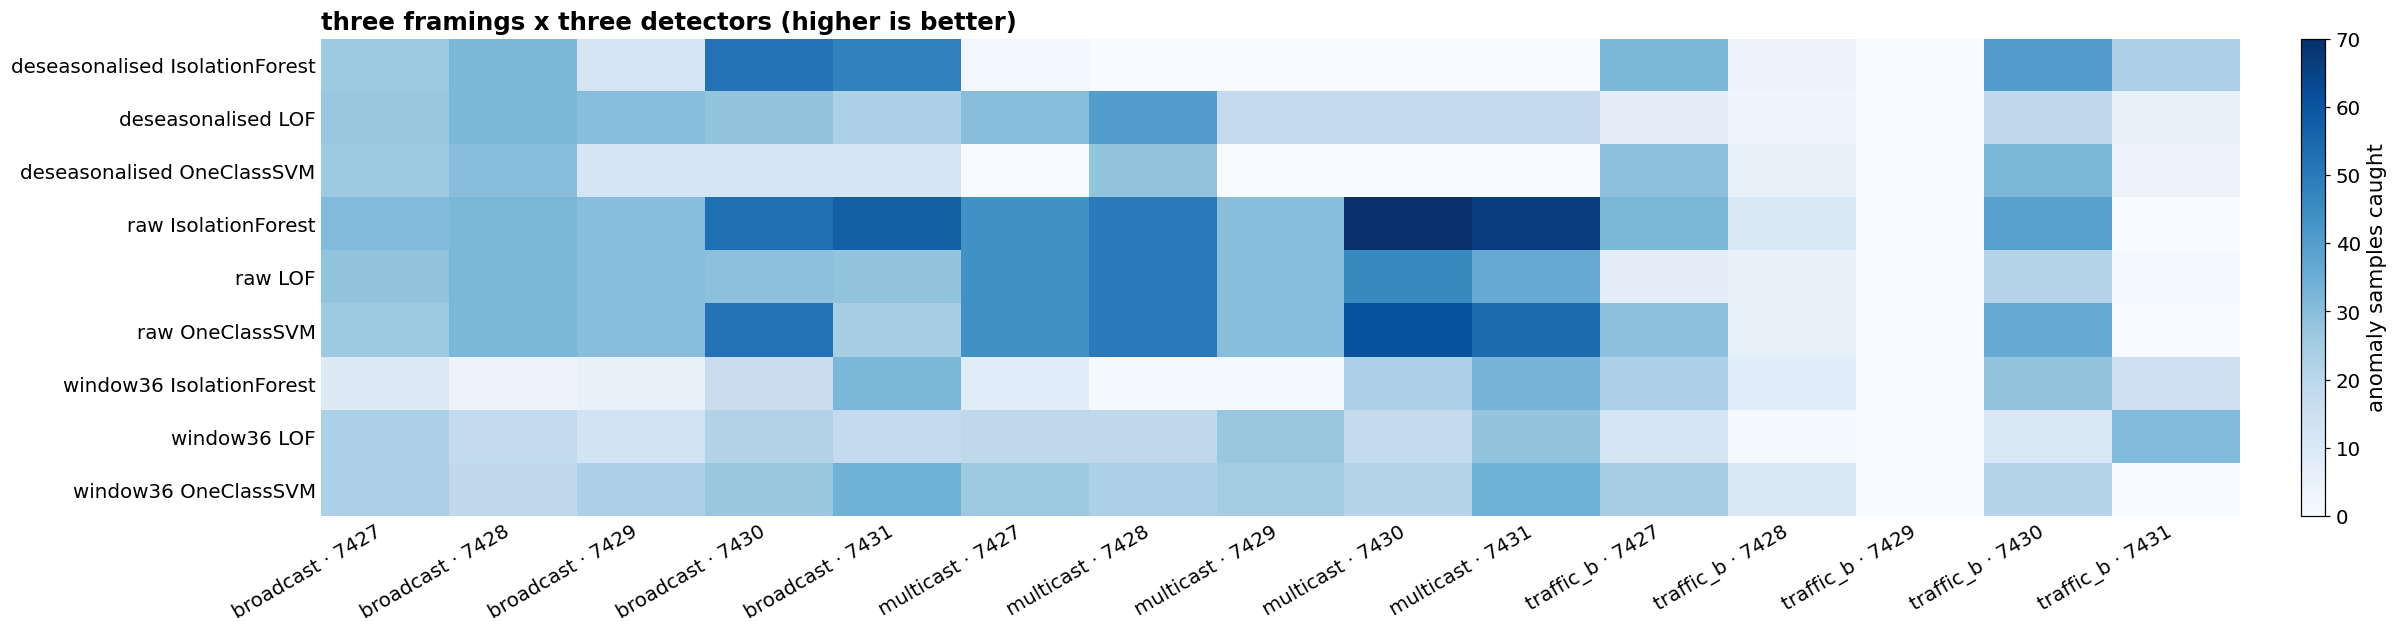

,port,method,alerts,caught,of,precision,column
0,7427,raw IsolationForest,87,32,62,0.368,traffic_bps
1,7427,raw OneClassSVM,87,29,62,0.333,traffic_bps
2,7427,raw LOF,87,7,62,0.080,traffic_bps
3,7427,deseasonalised IsolationForest,85,32,62,0.376,traffic_bps
4,7427,deseasonalised OneClassSVM,87,29,62,0.333,traffic_bps
...,...,...,...,...,...,...,...
130,7431,deseasonalised OneClassSVM,0,0,66,NaN,multicast_ratio
131,7431,deseasonalised LOF,87,18,66,0.207,multicast_ratio
132,7431,window36 IsolationForest,87,33,66,0.379,multicast_ratio
133,7431,window36 OneClassSVM,87,34,66,0.391,multicast_ratio


In [5]:
rows, scores = [], {}
for port, column in [(p, c) for c in COLUMNS for p in PORTS]:
    g = series_of(port=port, col=column, data=df)
    for name, (X, k, pad) in framings(g, port=port, col=column, n_input=N_INPUT,
                                      train_frac=TRAIN_FRAC, scalers=SCALERS).items():
        fitted = fit_models(X[:k], X)
        # a window's score belongs to the sample it ends on, so pad the leading samples
        fitted = {m: np.concatenate([np.full(pad, np.nan), s]) for m, s in fitted.items()}
        scores[port, column, name] = fitted
        for model, s in fitted.items():
            r = evaluate(name=f"{name} {model}", port=port, score=s,
                         target=g["target"], budget=BUDGET)
            rows.append({**r, "column": column})

framing_table = pd.DataFrame(rows)
grid = framing_table.pivot_table(index="method", columns=["column", "port"], values="caught")
grid.columns = [f"{c[:9]} · {p}" for c, p in grid.columns]
heatmap(grid, fmt="{:.0f}", cbar_label="anomaly samples caught",
        title="three framings x three detectors (higher is better)")
framing_table


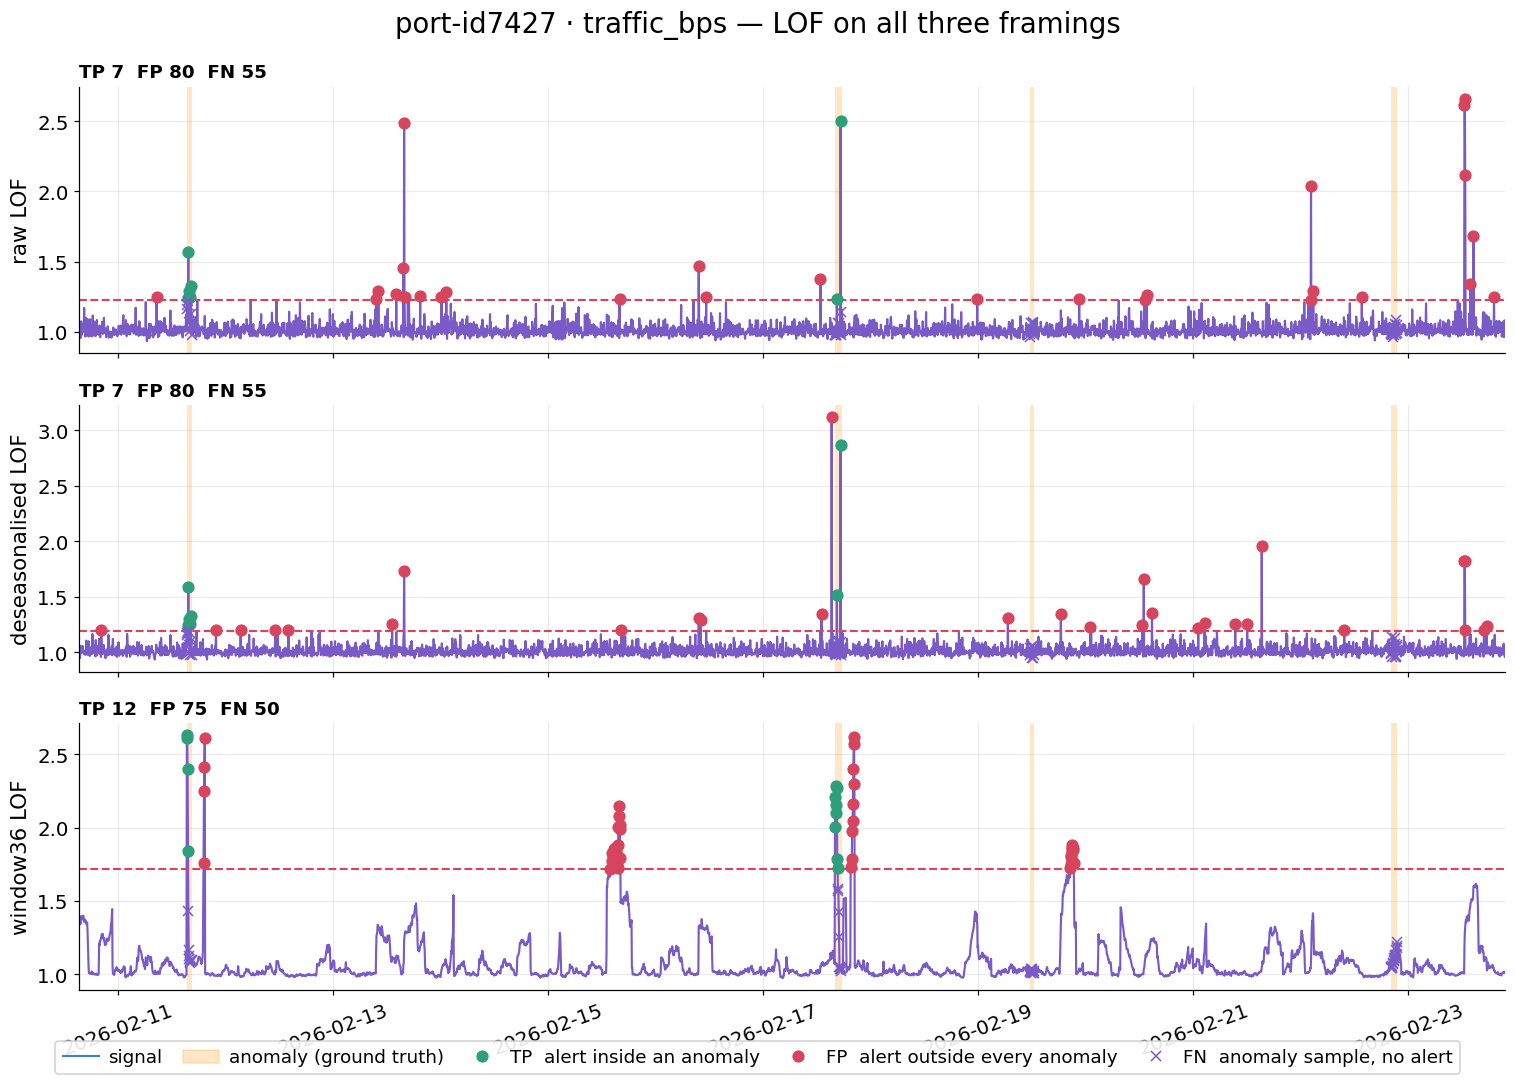

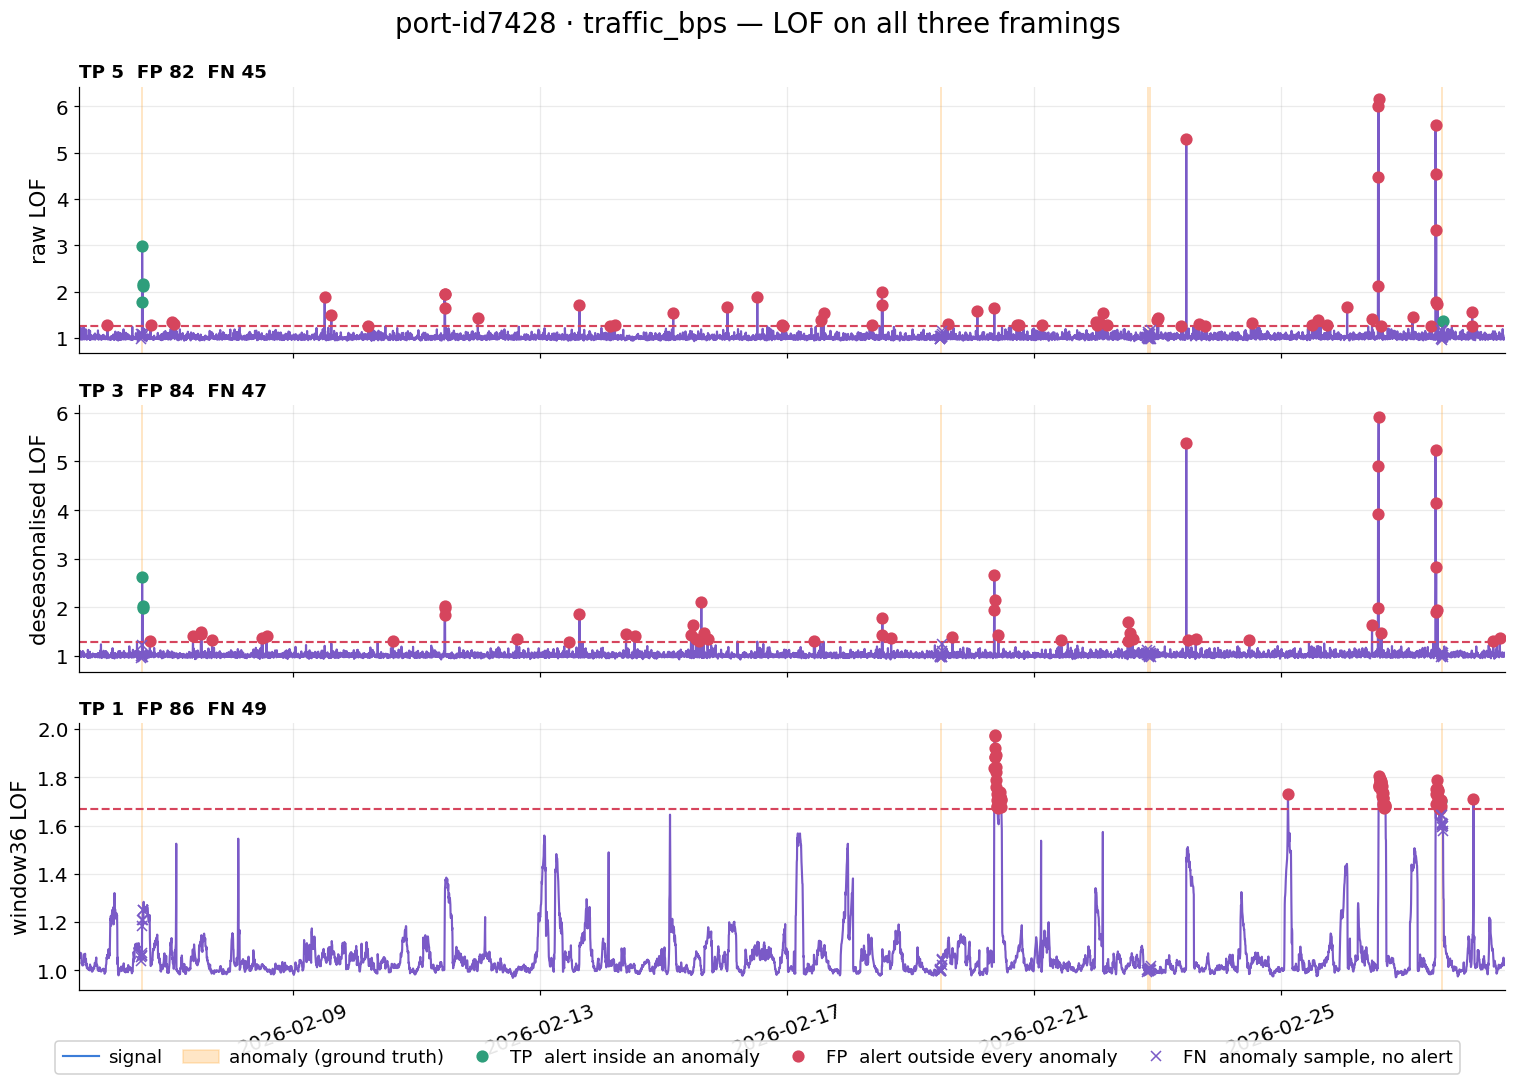

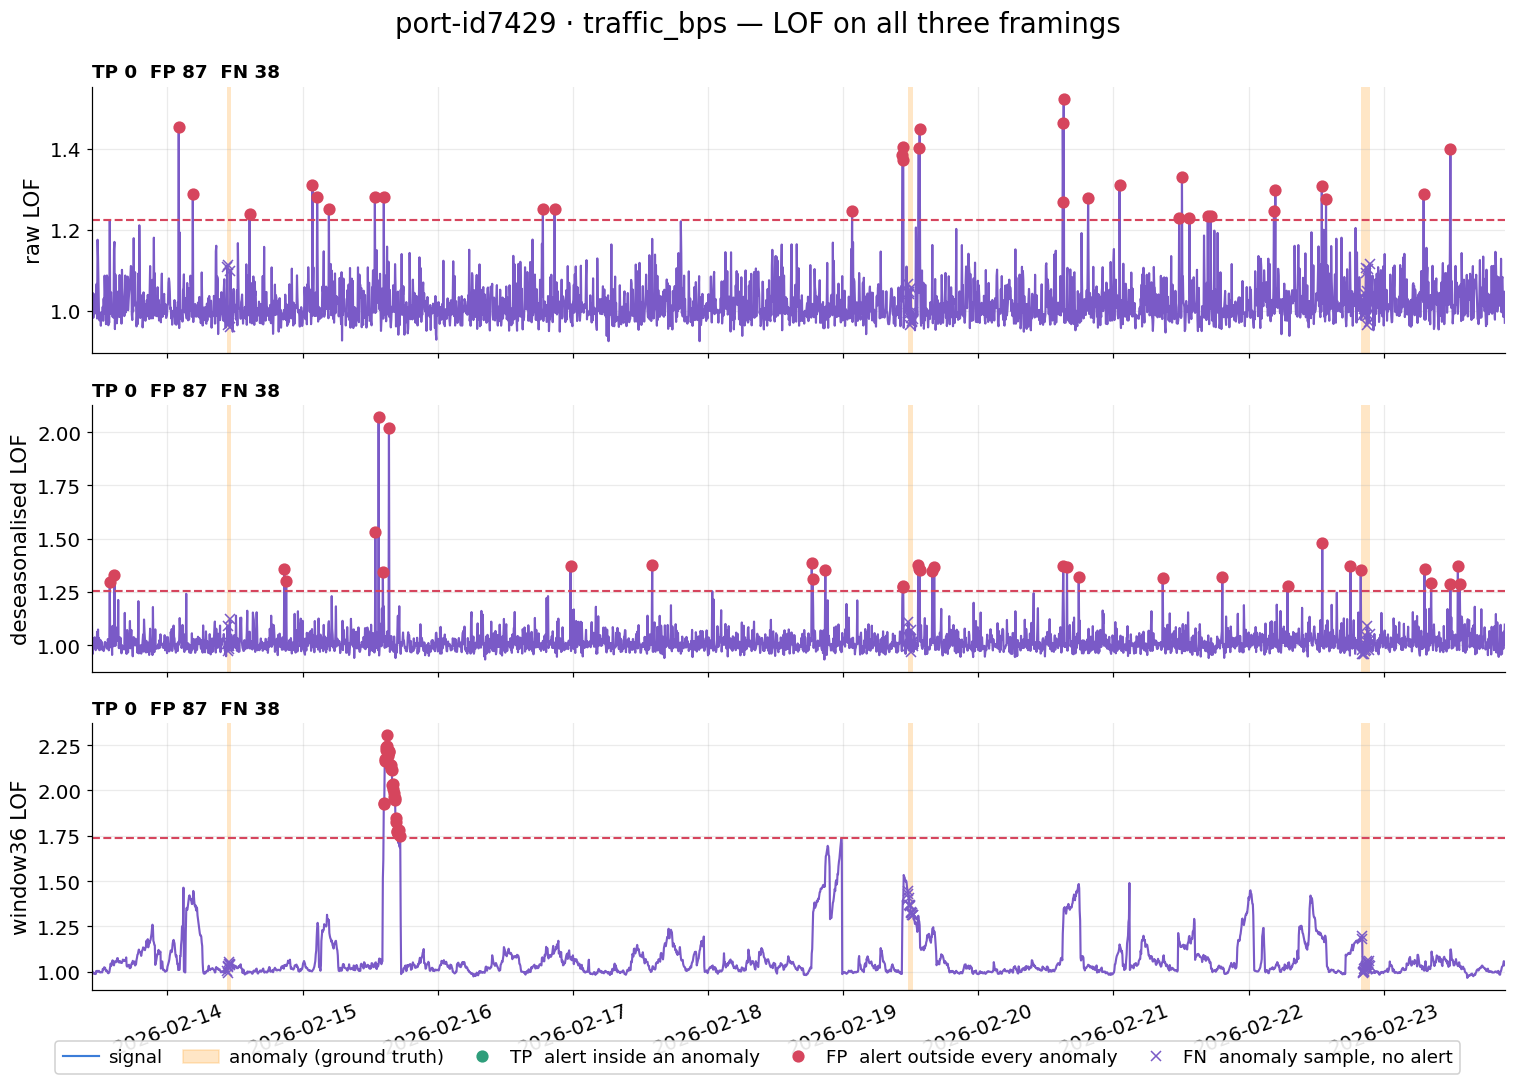

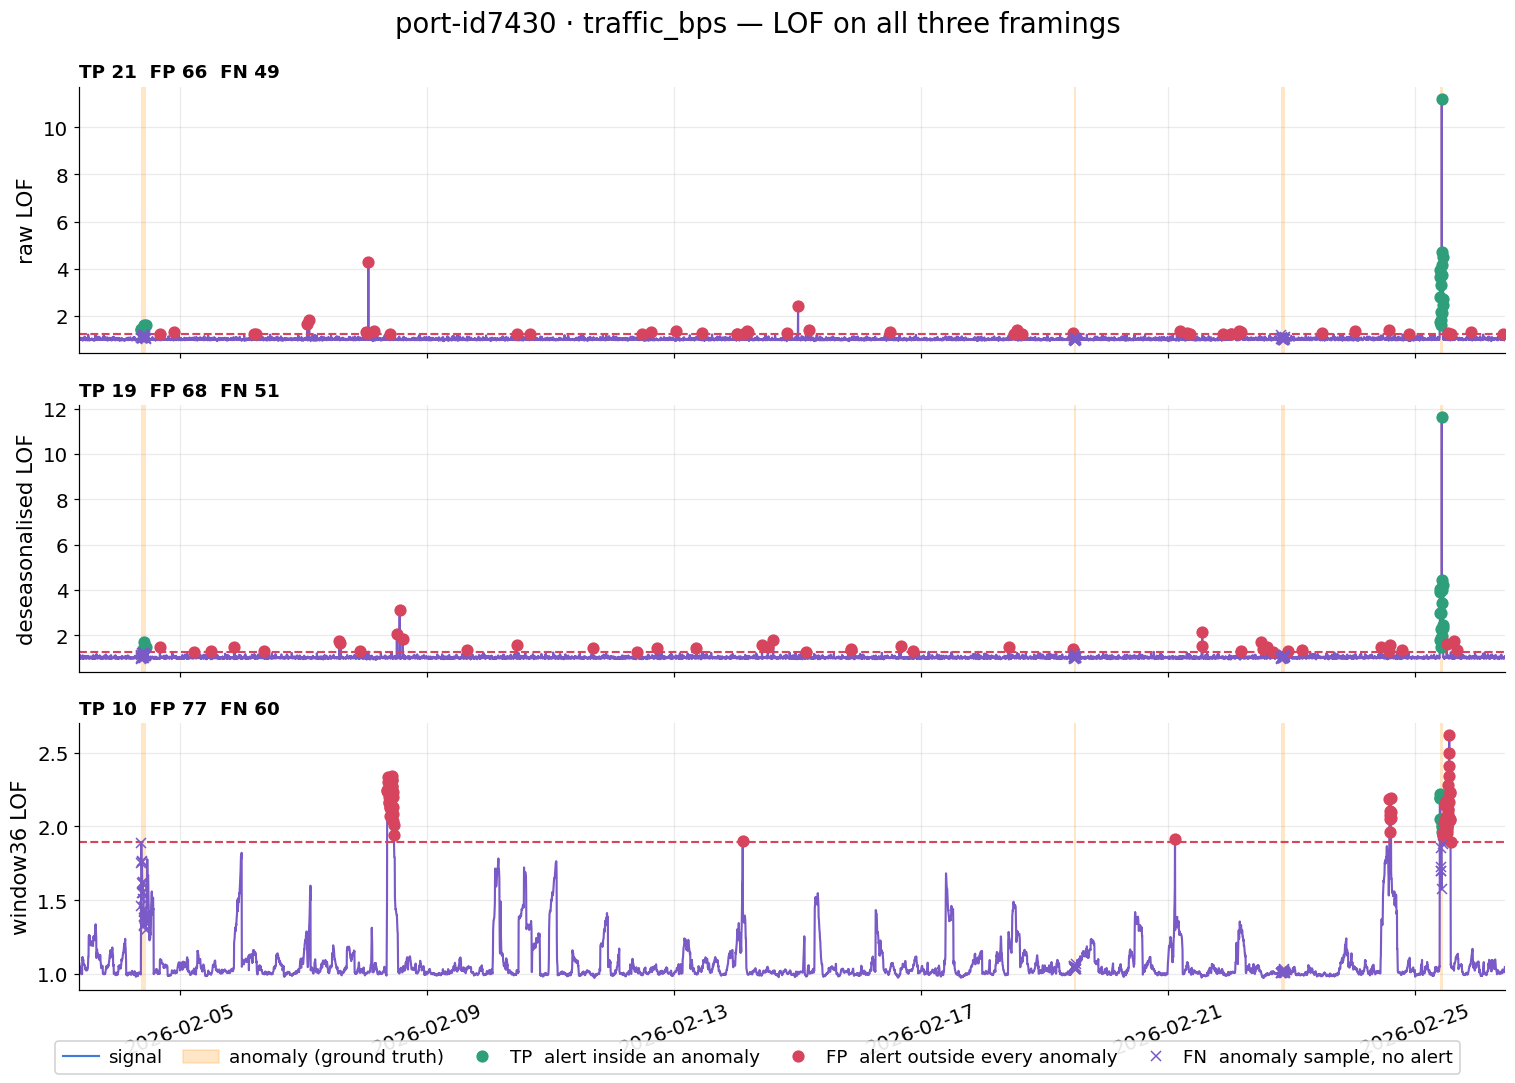

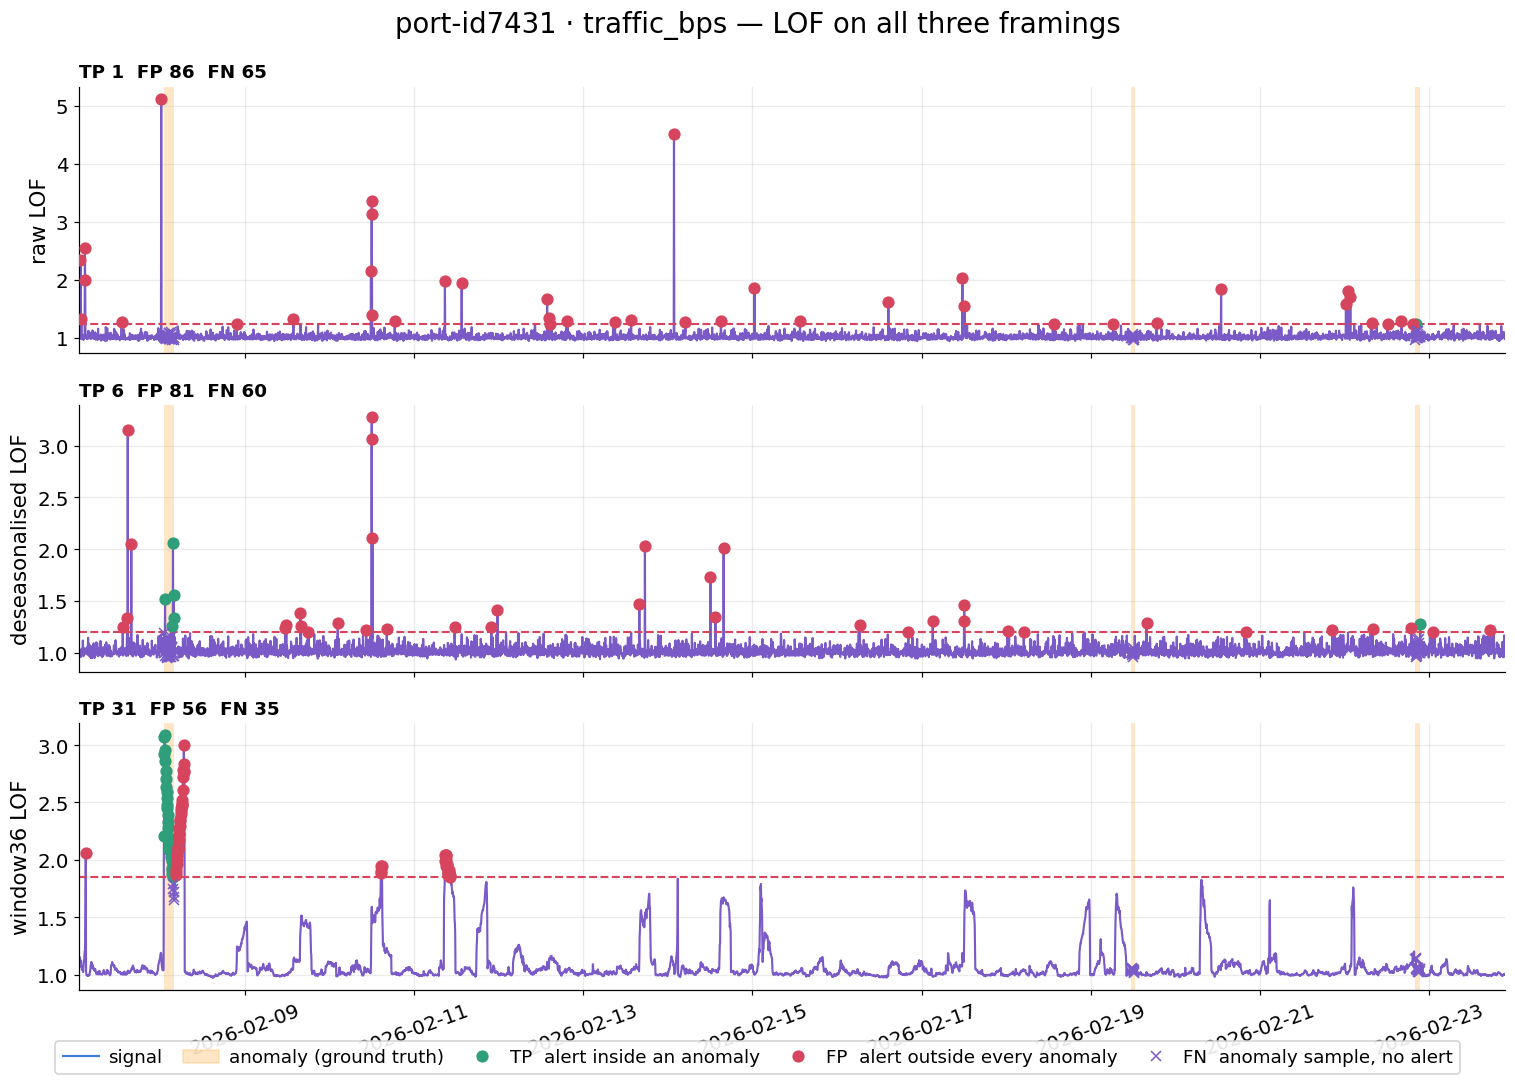

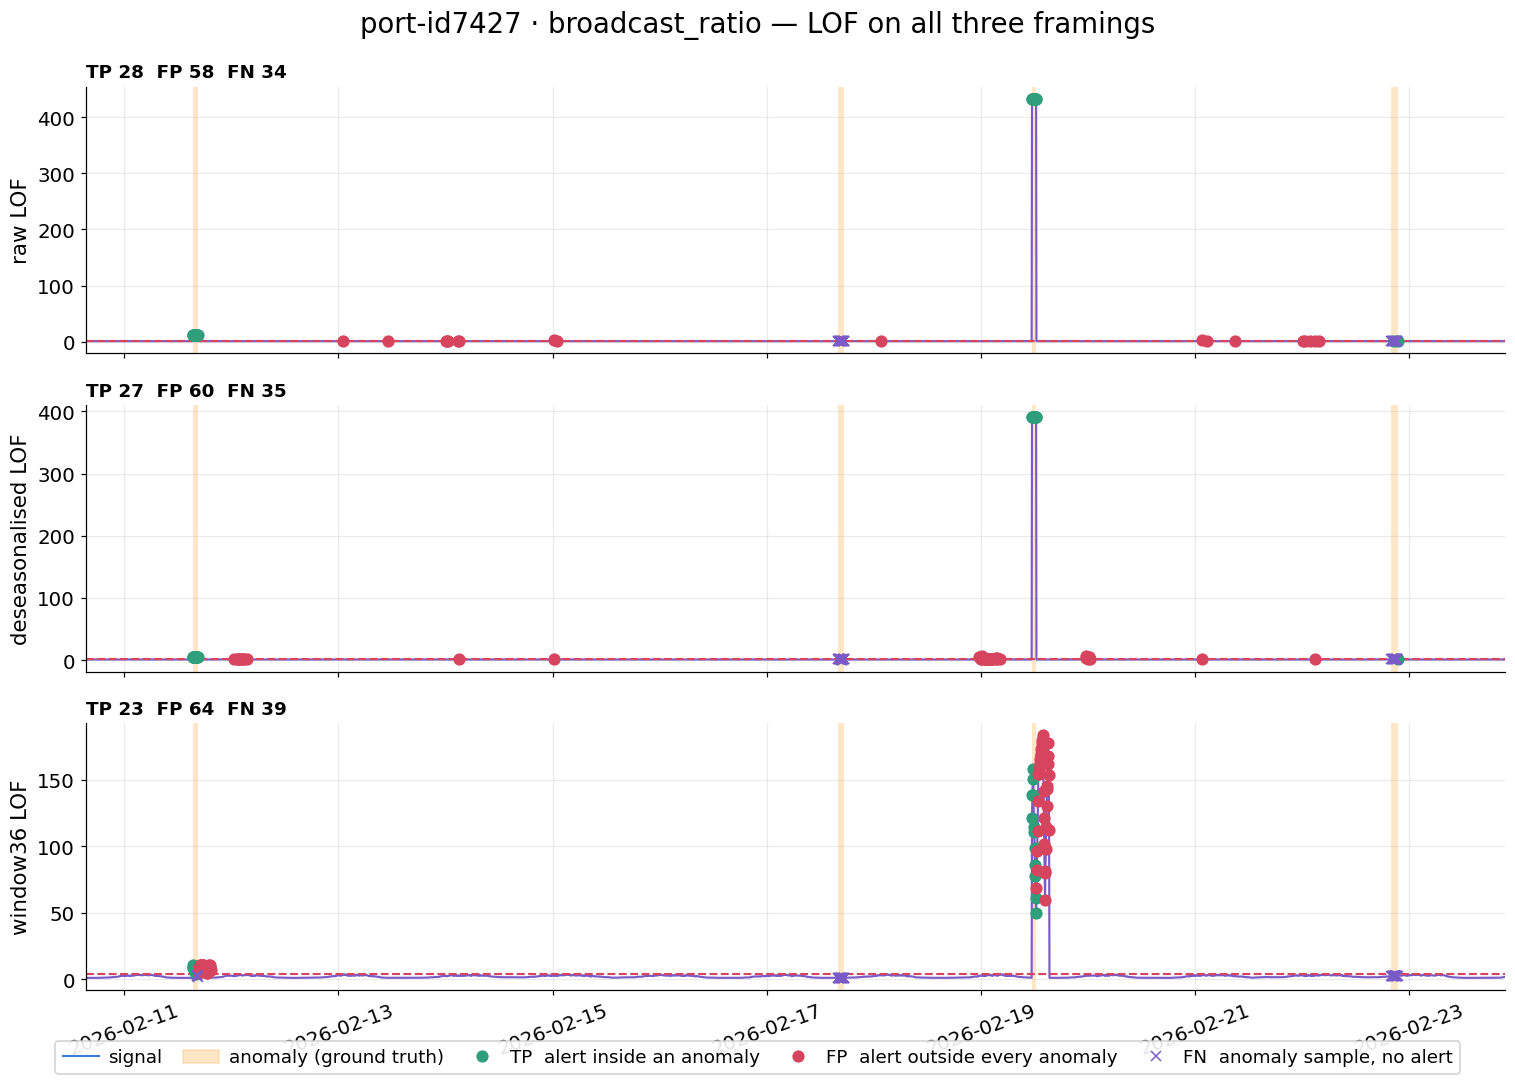

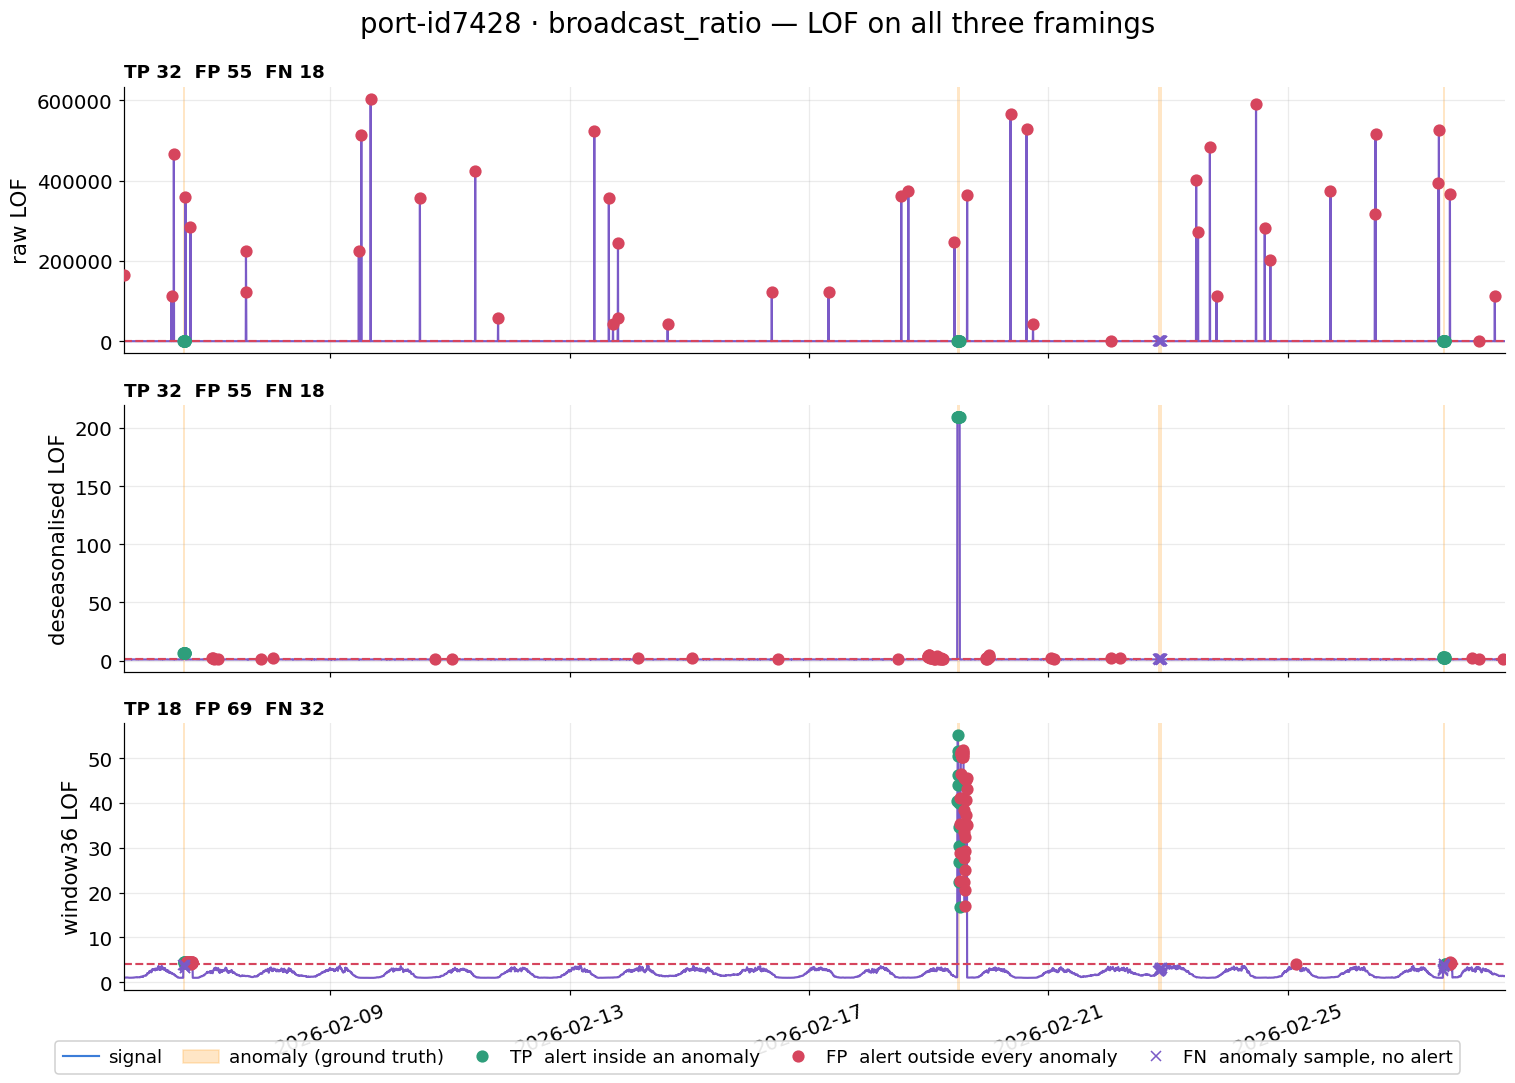

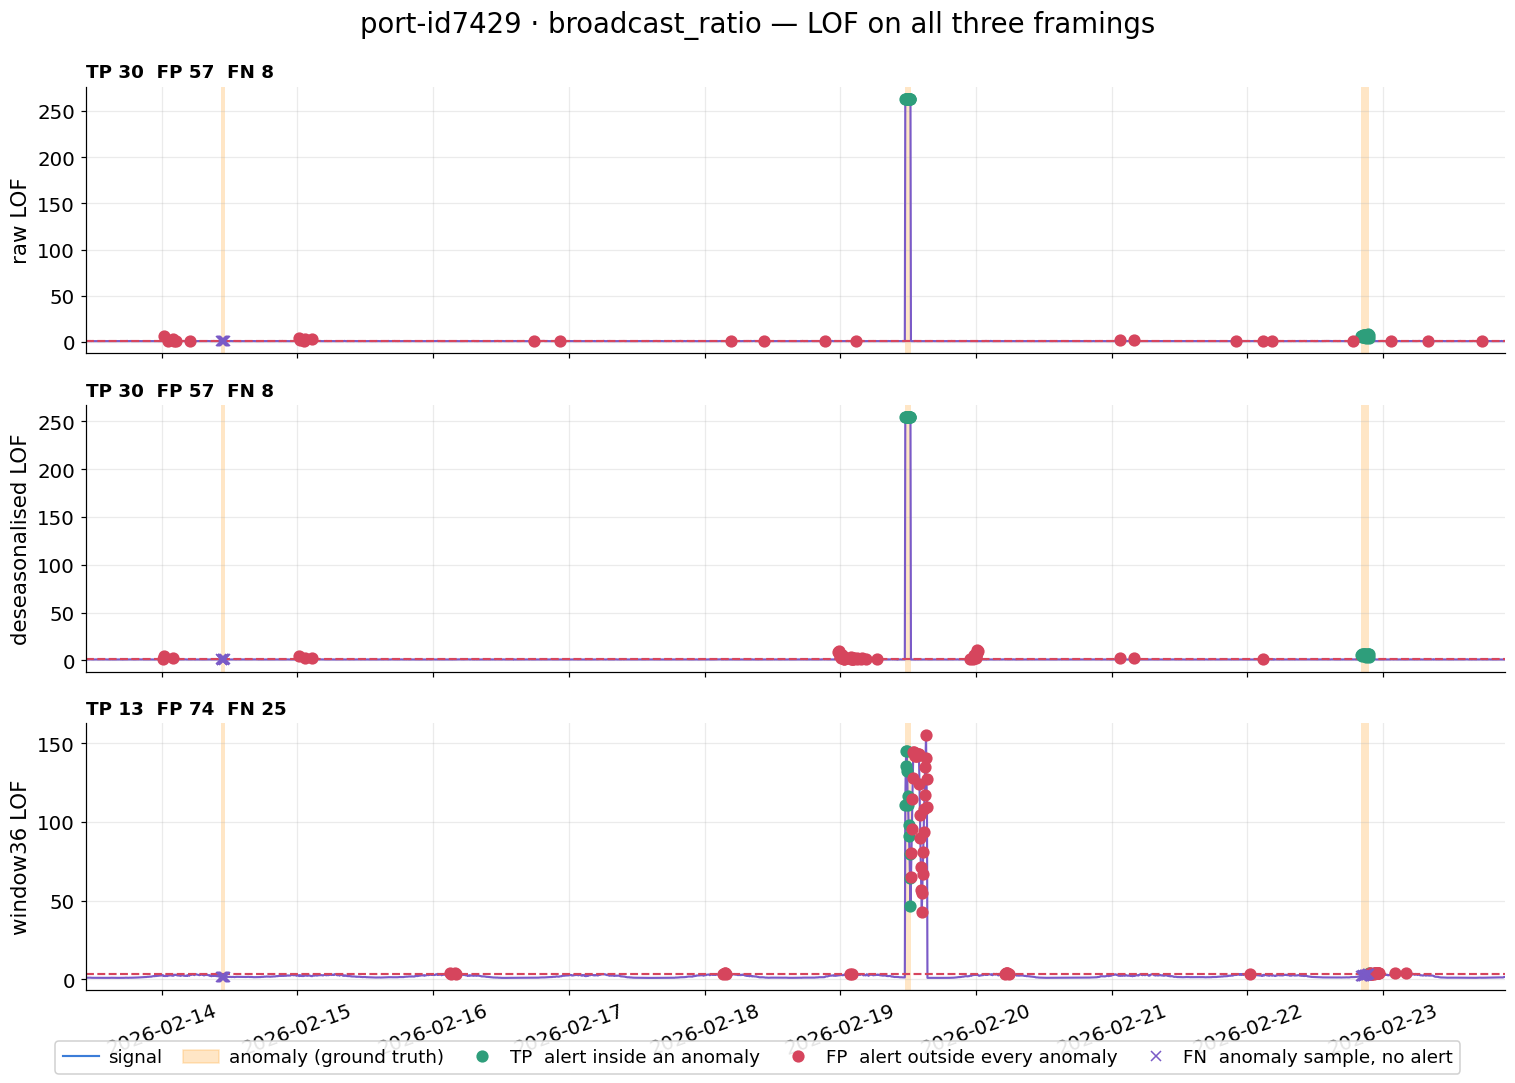

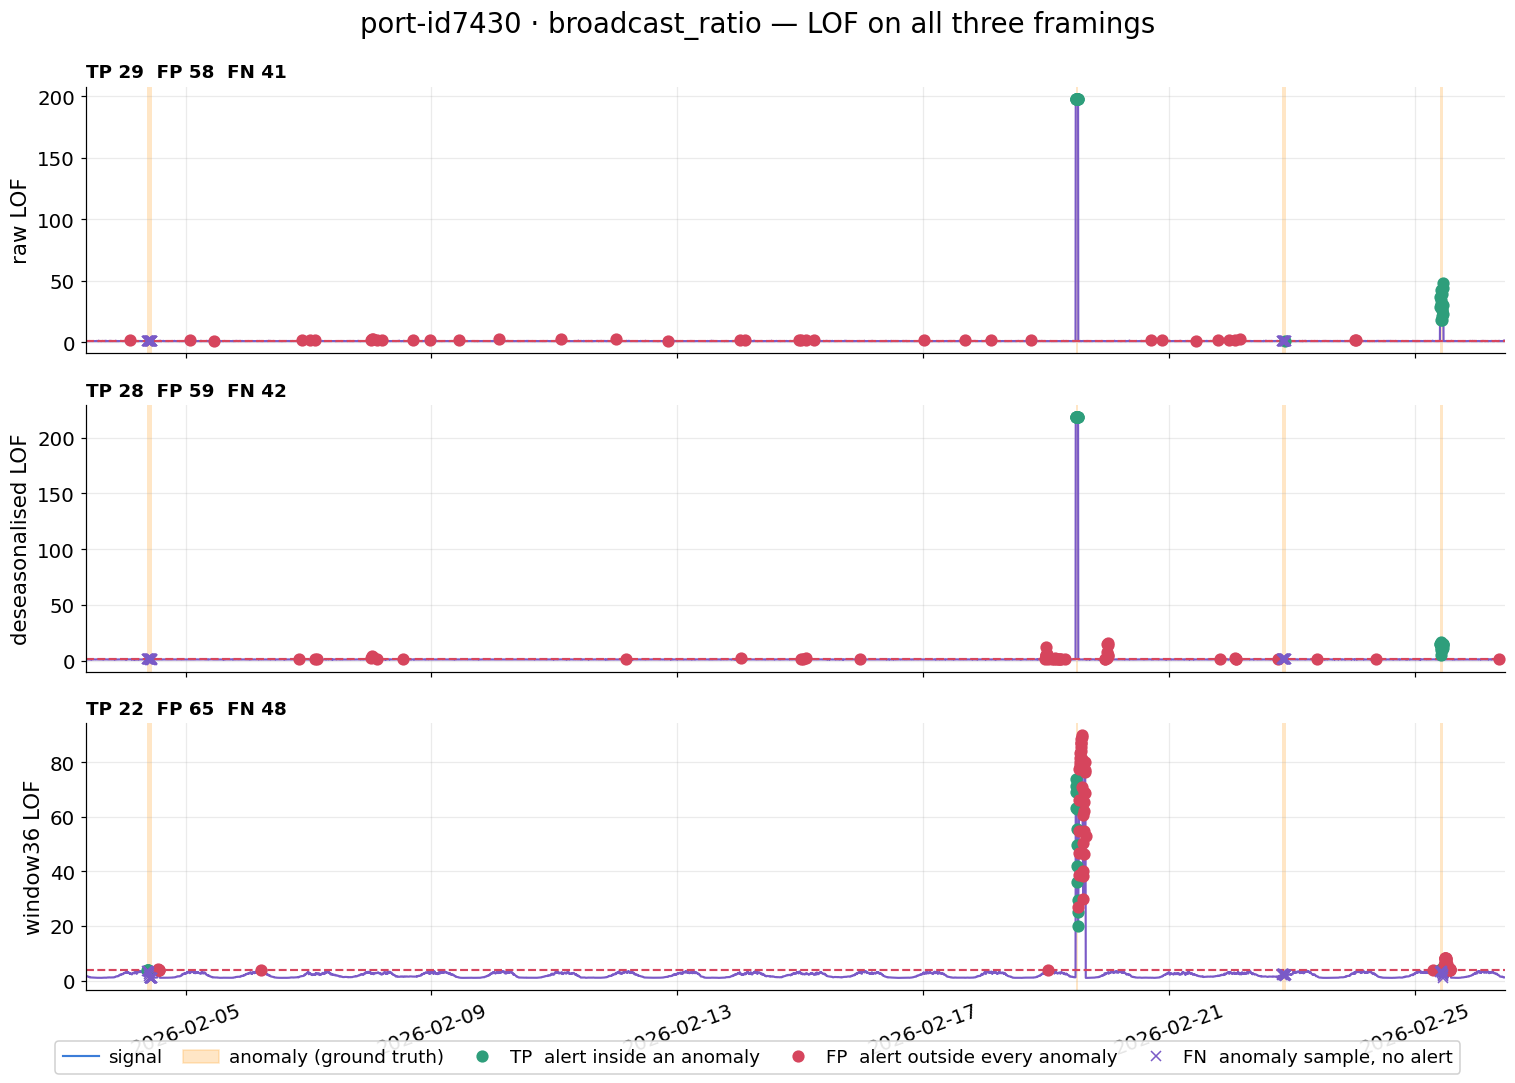

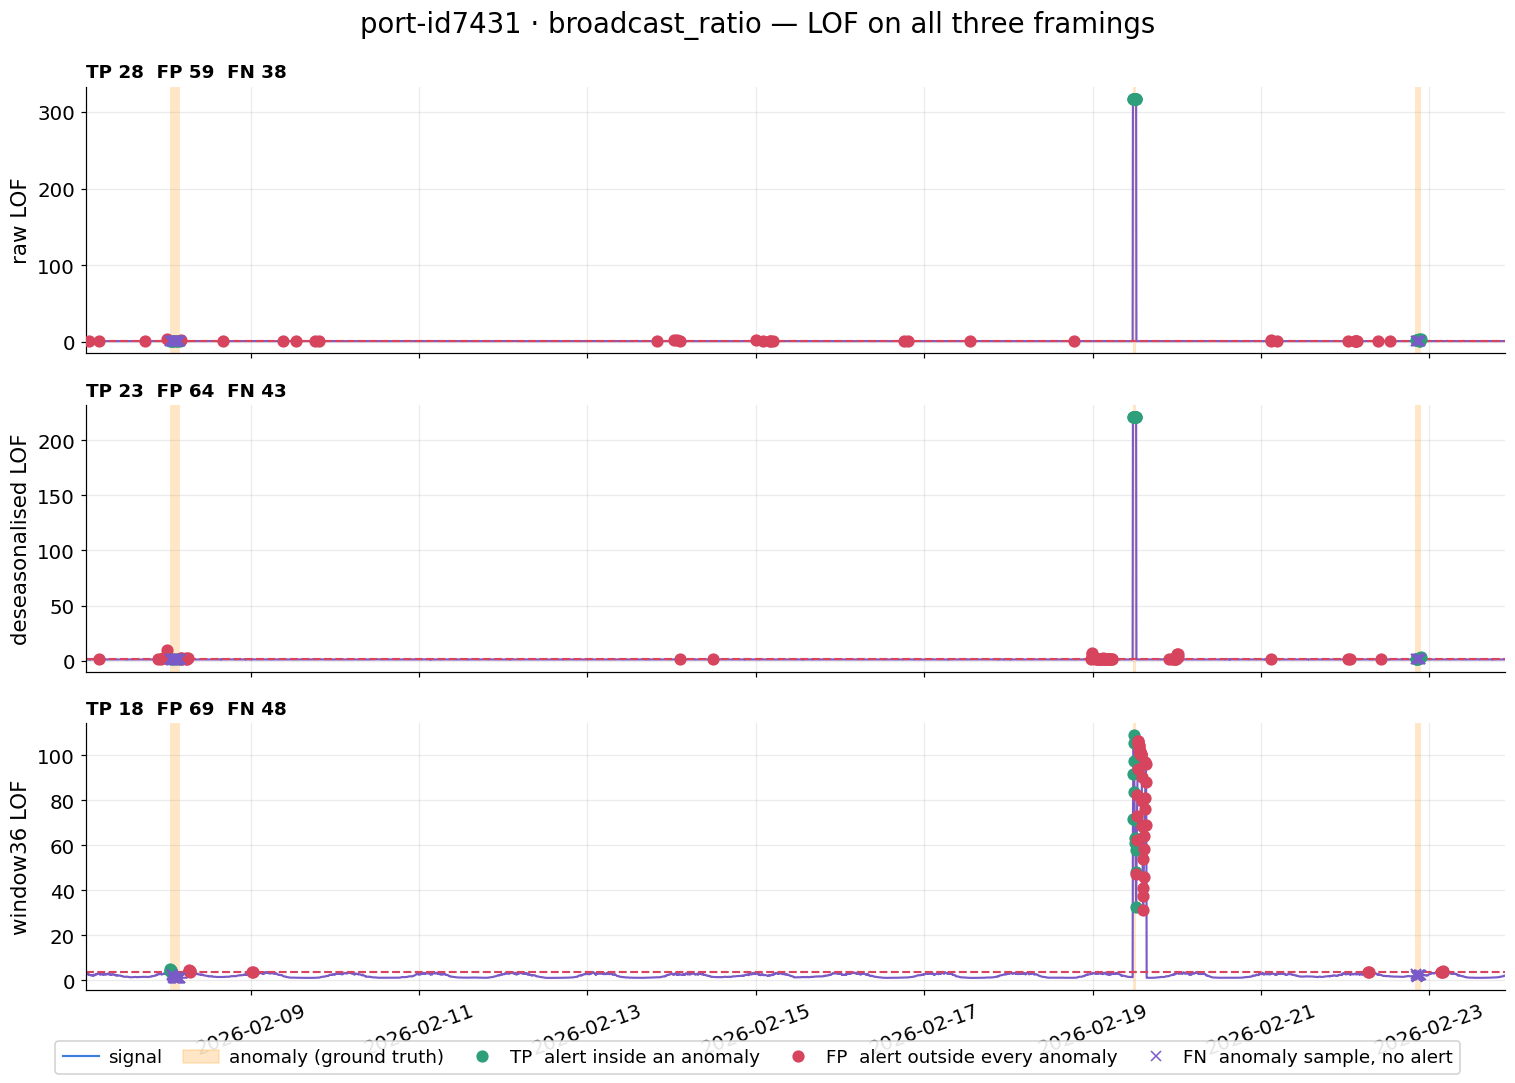

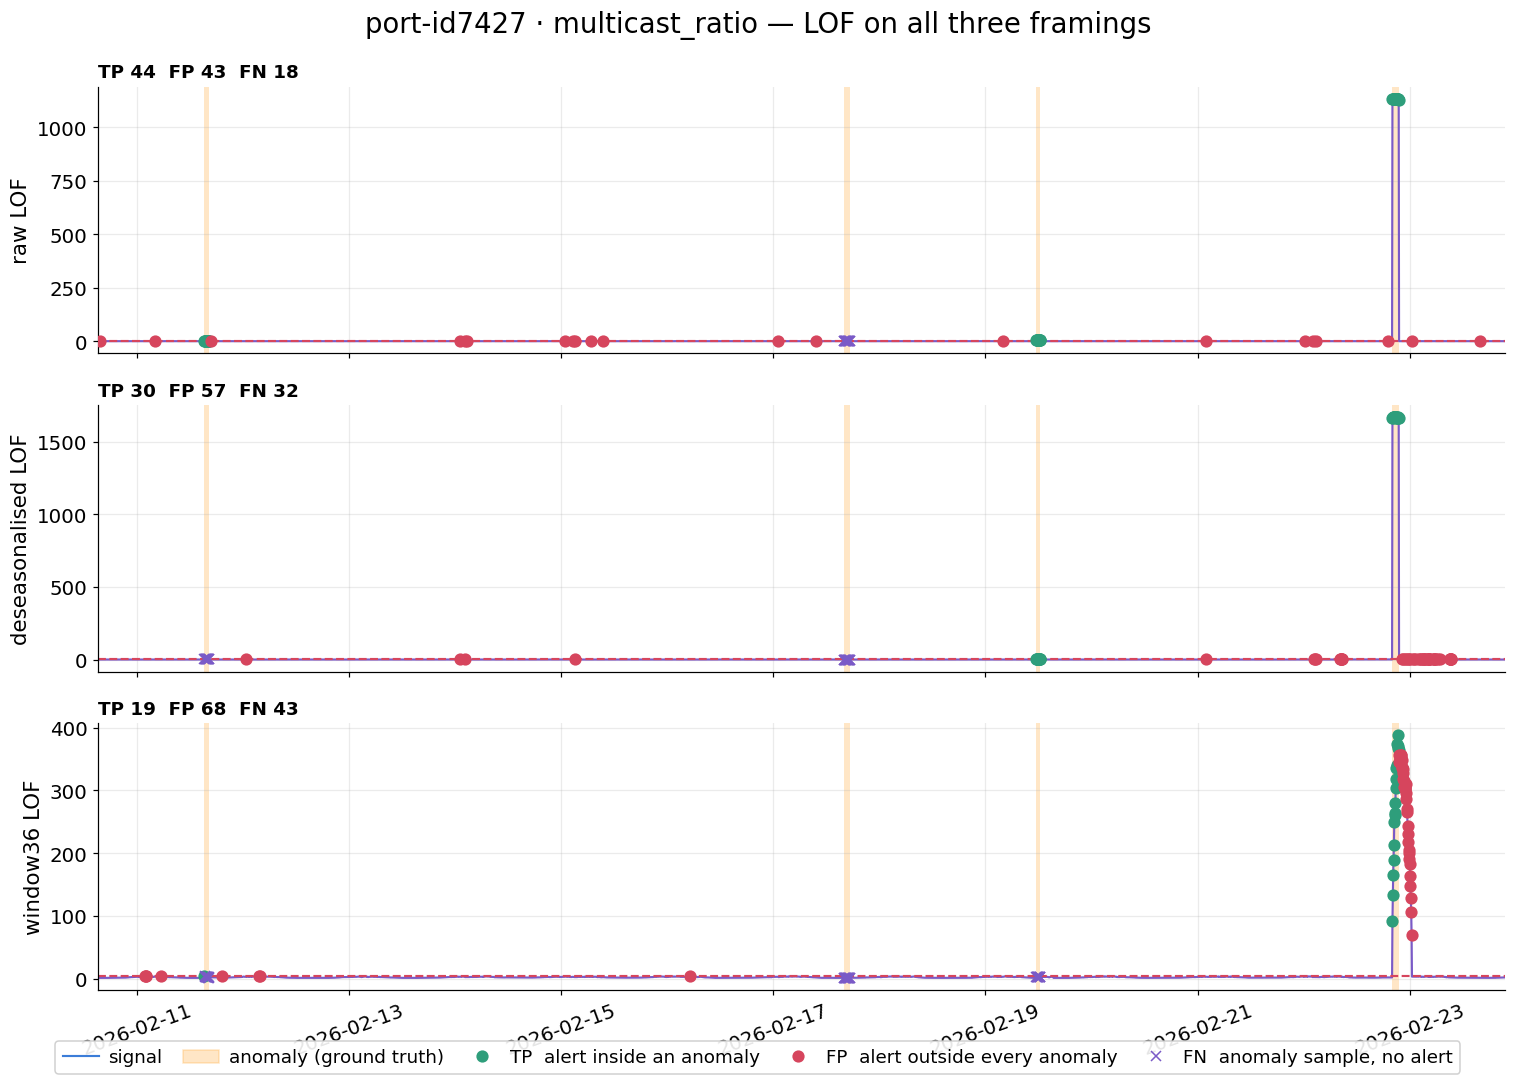

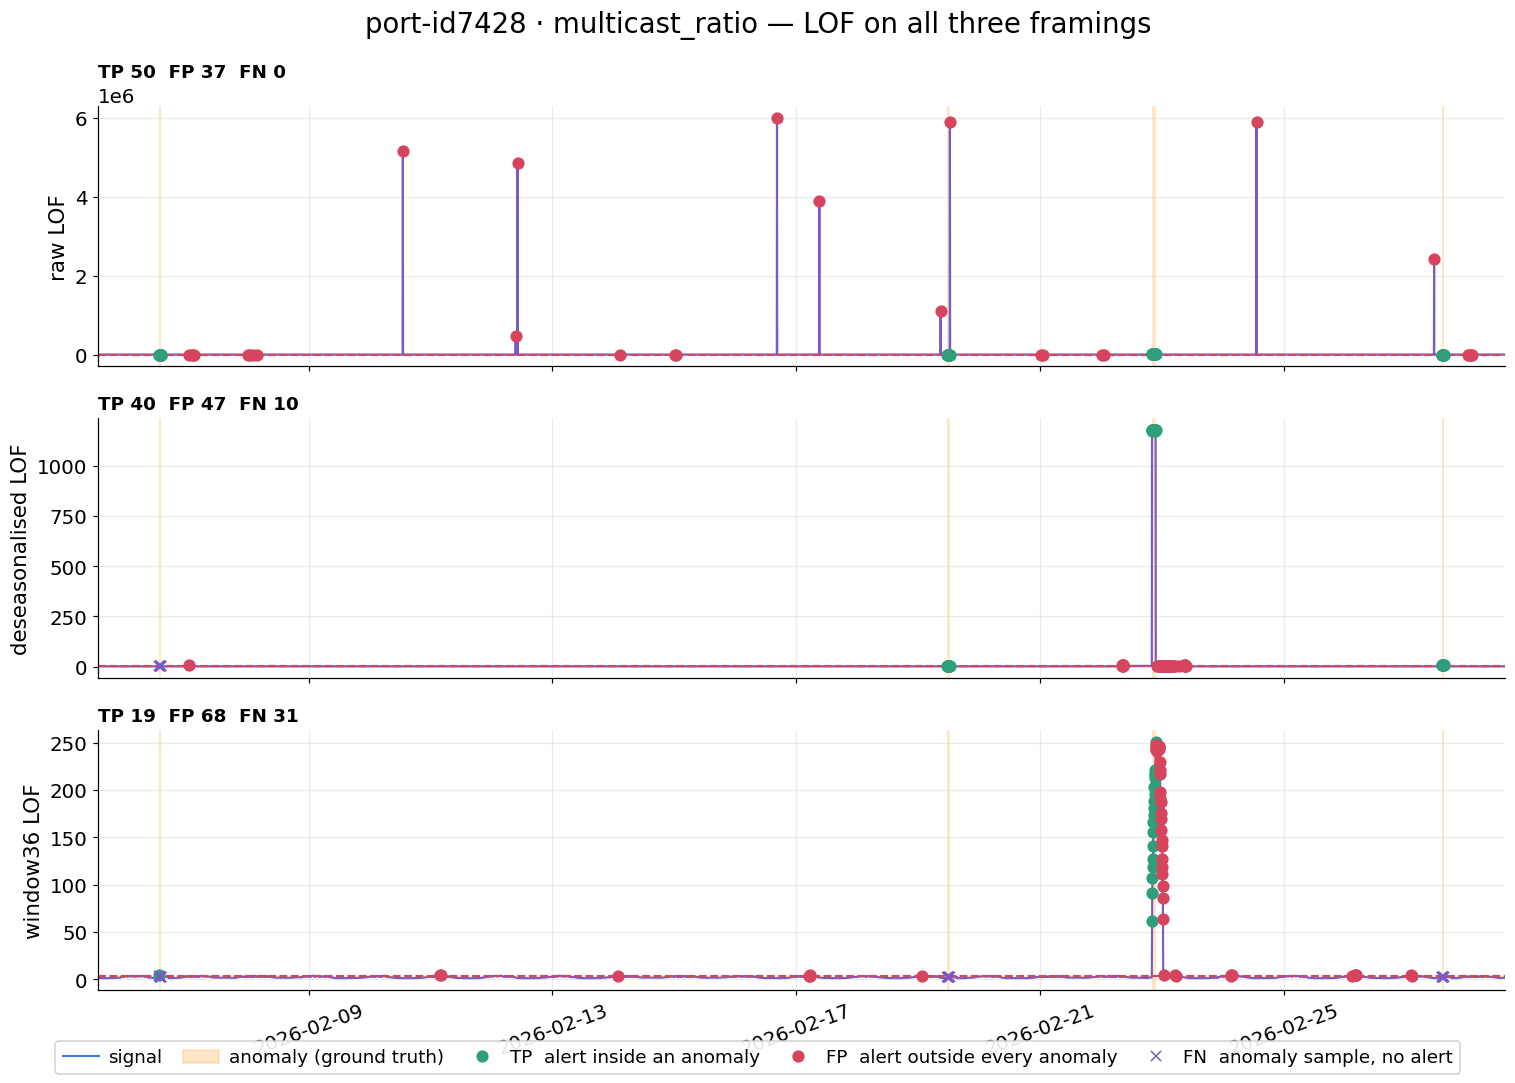

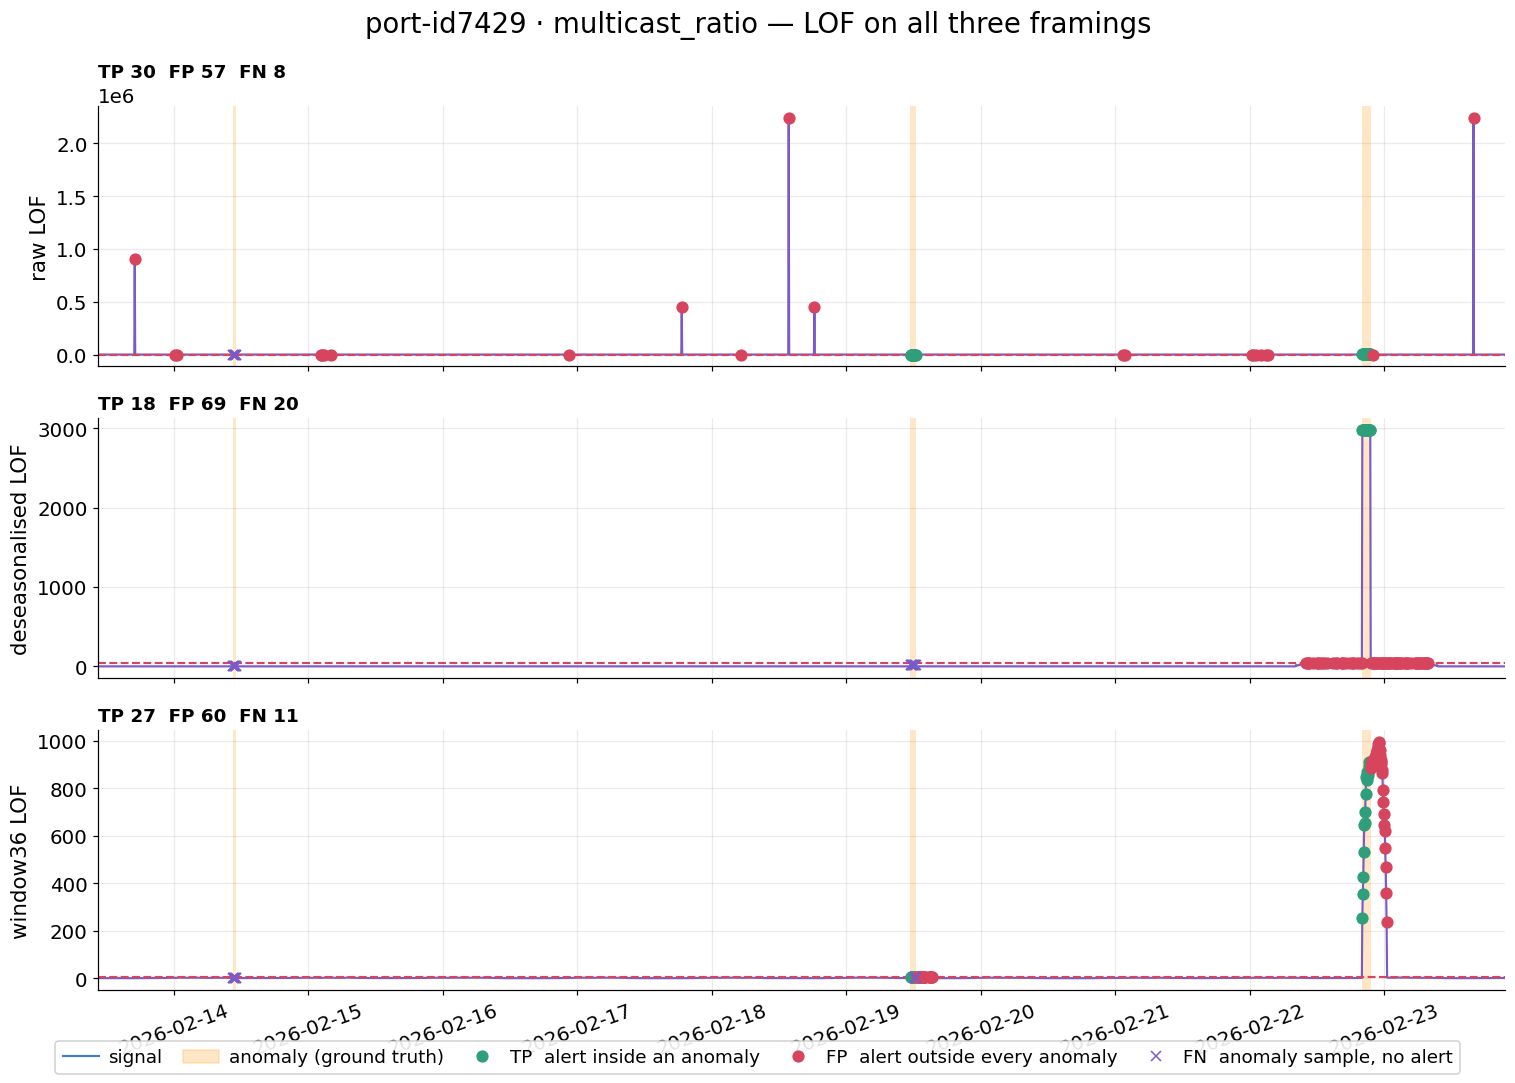

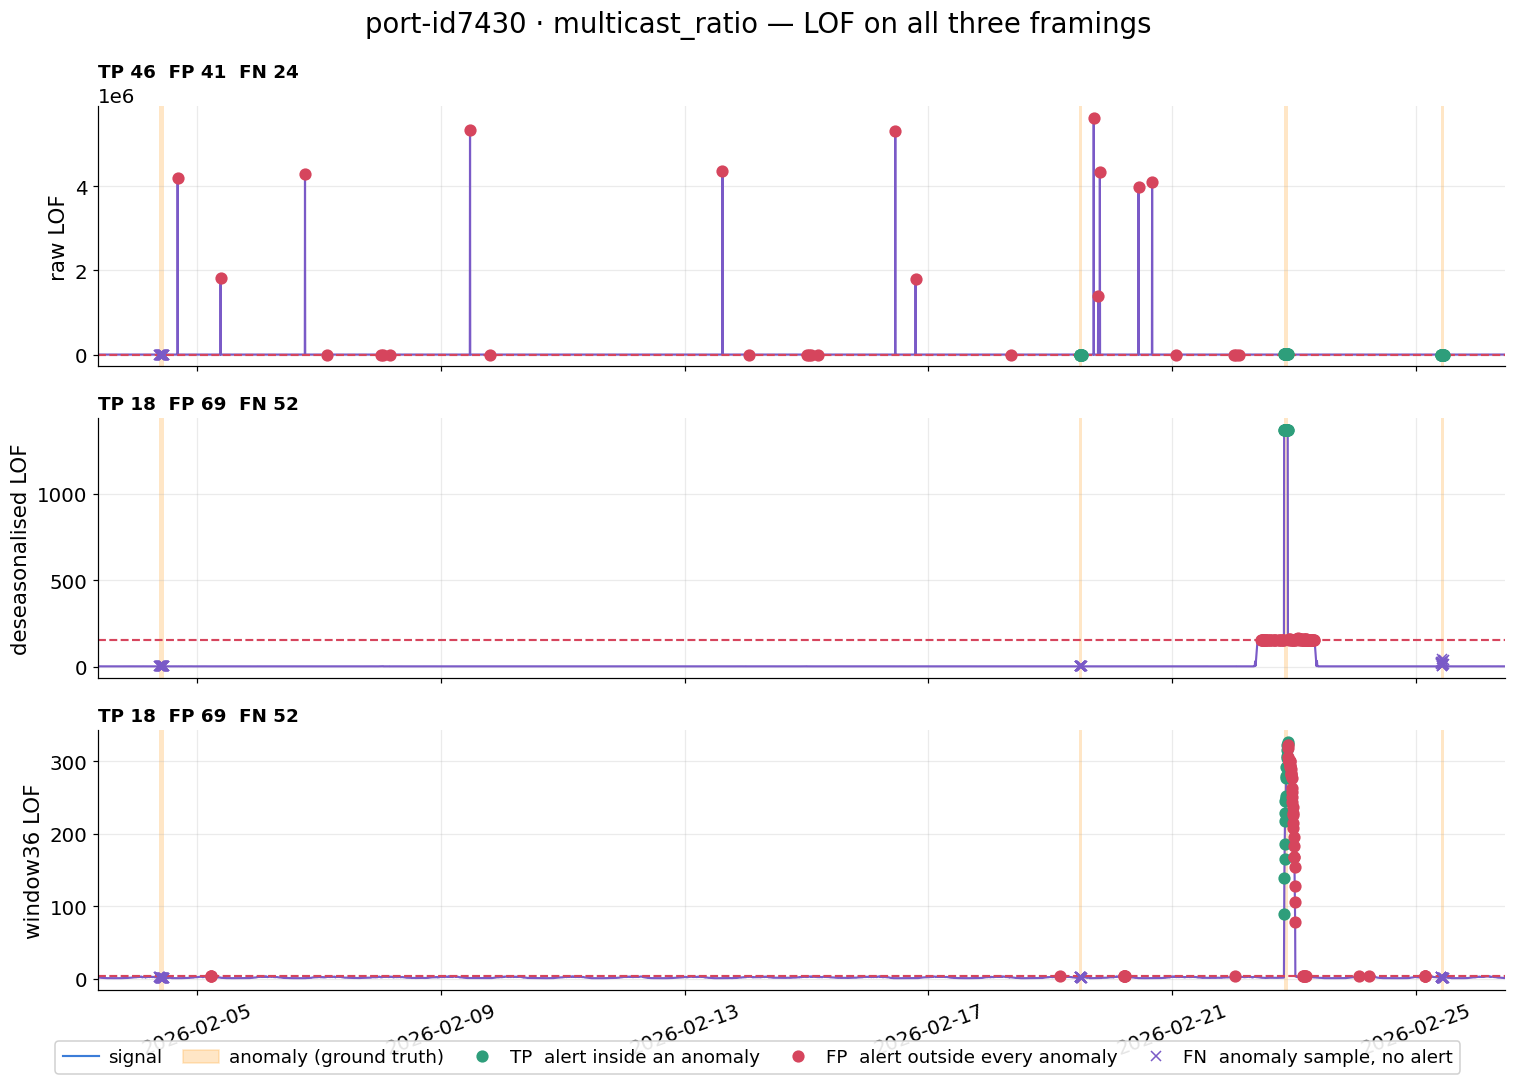

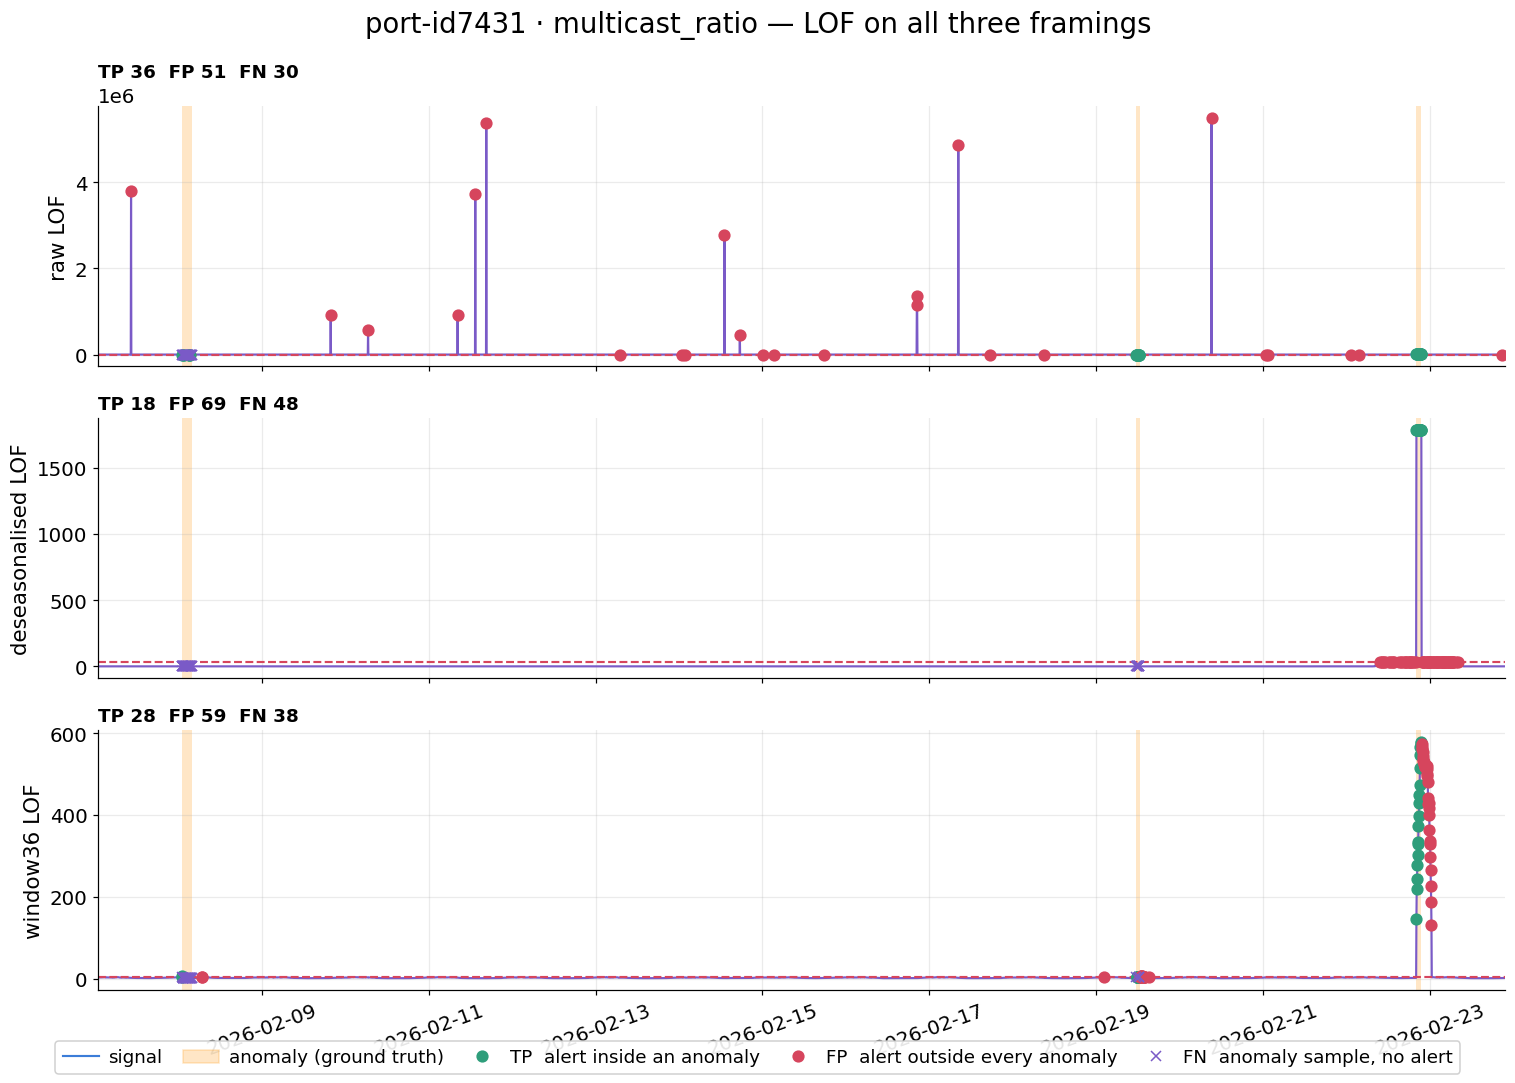

In [6]:
for port, column in [(p, c) for c in COLUMNS for p in PORTS]:
    plot_series(series_of(port=port, col=column, data=df), half=HALF, cadence=CADENCE,
                period=PERIOD,
                scores={f"{name} {m}": s
                        for name in ("raw", "deseasonalised", f"window{N_INPUT}")
                        for m, s in scores[port, column, name].items() if m == "LOF"},
                budget=BUDGET, title=f"{port} · {column} — LOF on all three framings")


Read the heatmap by column, because the three say different things — and only one of them says what
the textbook expects.

- **`traffic_bps` — deseasonalising helps, just.** 204 samples caught against 186 raw and 183
  windowed, summed over the five ports. It is the only column with a daily cycle to subtract, and the
  gain is real but small.
- **`multicast_ratio` — deseasonalising is a catastrophe.** 705 caught raw, **154** deseasonalised.
  Subtracting a seasonal profile fitted to a column that has no season removes signal and leaves
  noise.
- **`broadcast_ratio` — the same direction, less violently.** 514 raw, 402 deseasonalised, 286
  windowed.

**So the remedy that is supposed to be the sophisticated choice loses on two of three columns.** Lab
01 Step 10b measured why before any model ran: the ratio columns have an autocorrelation of −0.001 at
a one-day lag. A transform that assumes a cycle, applied where there is none, is not neutral.

**The models are closer together than the framings are.** IsolationForest 1021 total, OneClassSVM
974, LOF 945 — a 8% spread, against the 4.6× spread between raw and deseasonalised on
`multicast_ratio`. **On this data the framing decides and the model barely matters,** which is the
opposite of where most tuning effort goes.

**Seven of the 135 rows emit no alerts at all.** A detector that fires nothing still occupies a row
in a comparison table, and precision is undefined rather than bad.

## Step 6 — Change points: did the system move to a new level?

- **Everything so far asks whether a sample is far from a baseline. A change point asks whether
  the process changed.** A deployment moving memory 40% → 65% produces no outlier at all — every
  point-wise detector stays silent while the system is permanently different.

**Two-window score** — compare the window before $t$ against the window after:

$$\mathrm{score}_t = \left| \mathrm{mean}(x_{t-w \ldots t}) - \mathrm{mean}(x_{t \ldots t+w}) \right|$$

- Uses the future, so it's offline. Online: compare an older reference window against a recent
  detection window and accept the delay.

**CUSUM** — accumulate small deviations instead of thresholding each one:

$$S_t = \max(0,\; S_{t-1} + z_t - k)$$

- A persistent shift too small to trip a per-sample cutoff adds up until $S_t$ crosses `h`.
- `k` — the deviation you agree to ignore. `h` — how much accumulated evidence justifies acting.

In [ ]:
def two_window(x, w, online=False):
    """|mean(previous w) - mean(next w)| at every point.

    online=True compares two windows that both sit in the past, separated by a gap of w, which is
    what a live detector can actually compute. The offline form is centred on t and peaks exactly
    at the change; the online form peaks w samples later.
    """
    s = pd.Series(np.asarray(x, dtype=float))
    before = s.rolling(w, min_periods=w // 2).mean()
    after = before.shift(-w) if not online else before.shift(w)
    return (before - after).abs() if online else (after - before).abs()


def cusum(z, k=1.5, h=5.0):
    """One-sided CUSUM on a standardised series, resetting after each alarm.

    Returns (statistic, alarm mask). Without the reset the statistic ratchets upward and every
    later sample inherits the first excursion.

    The returned statistic holds the value at the moment of crossing rather than the post-reset
    zero, so a plotted peak actually touches the limit line and the alarm marker sits on it.
    """
    z = np.asarray(z, dtype=float)
    S = np.zeros(len(z))
    alarm = np.zeros(len(z), bool)
    run = 0.0
    for t in range(1, len(z)):
        run = max(0.0, run + z[t] - k)
        S[t] = run
        if run > h:
            alarm[t] = True
            run = 0.0
    return S, alarm


port = PORTS[1]                      # the port whose calendar entry claims a level shift
g = series_of(port)
level = g["value"].rolling(PERIOD, min_periods=PERIOD // 2).mean()     # for the display panel
# Applied to the raw series, not to `level`: `level` is already a rolling mean, and running a
# second one over it would smooth the very step the score exists to find.
tw = two_window(g["value"], PERIOD, online=True)

resid = g["resid"].to_numpy()                    # Lab 01 Step 15, read rather than recomputed
train = resid[:int(TRAIN_FRAC * len(resid))]
z = (resid - train.mean()) / train.std()
S, alarm = cusum(z, k=1.5, h=5.0)

peak = int(tw.idxmax())
print(f"{port}")
print(f"  two-window peak at {g['timestamp'][peak]} "
      f"({g['timestamp'][peak].day_name()}, label {g['event_label'][peak]})")
# every local maximum in the top decile, kept 12 h apart, with the weekday it fell on
v = np.nan_to_num(tw.to_numpy())
kept = []
for i in np.argsort(-v):
    if v[i] < tw.quantile(0.90):
        break
    if all(abs(i - j) > PERIOD // 2 for j in kept):
        kept.append(int(i))
print("  every top-decile peak:",
      ", ".join(f"{g['timestamp'][i]:%m-%d} {g['timestamp'][i].day_name()[:3]}"
                for i in sorted(kept)))
print(f"  CUSUM: {alarm.sum()} alarms, {int((alarm & g['target'].to_numpy()).sum())} inside a "
      f"anomaly window, {(alarm & ~g['target'].to_numpy()).sum() / DAYS:.2f} per day outside")


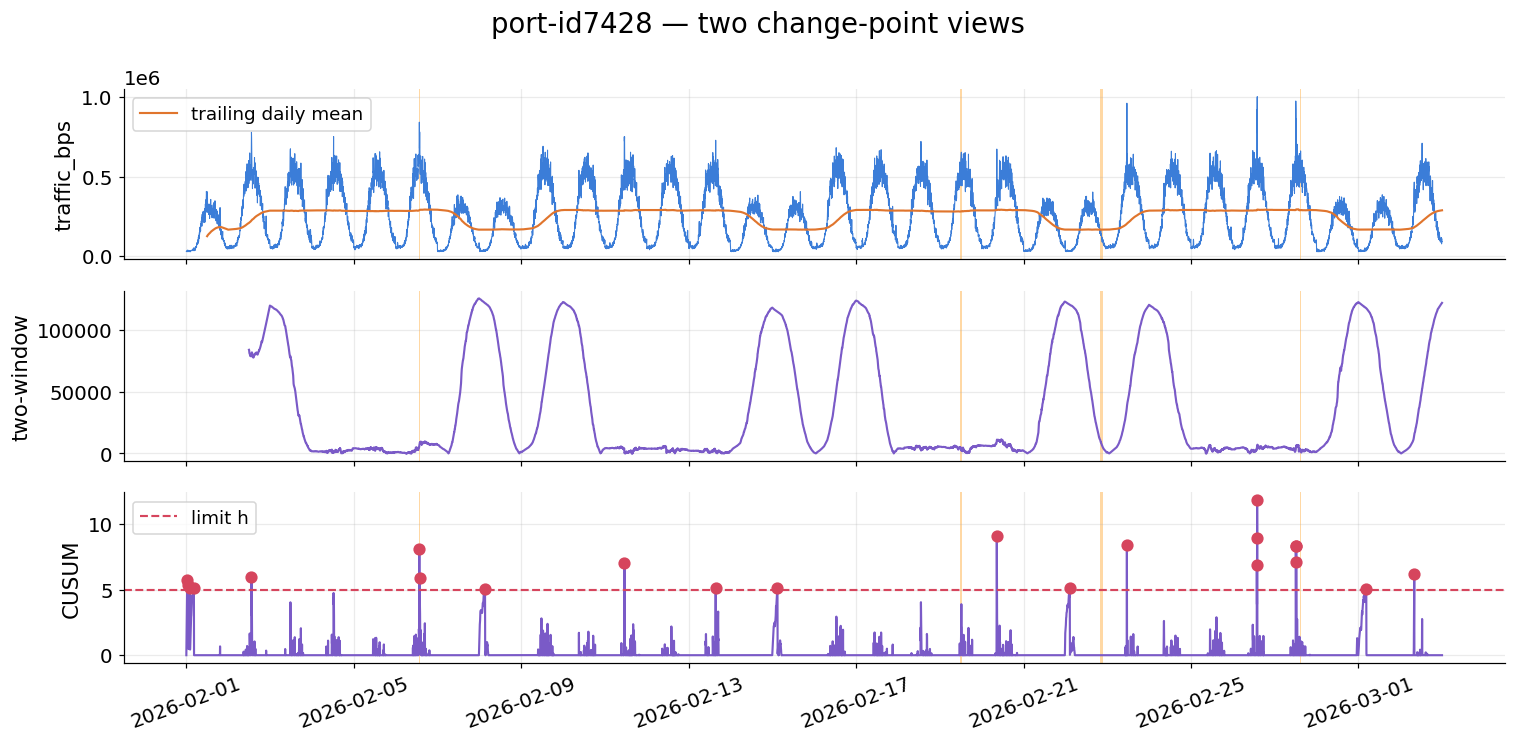

In [8]:
w, h = plt.rcParams["figure.figsize"]
fig, axes = plt.subplots(3, 1, figsize=(w, h * 1.5), sharex=True)
axes[0].plot(g["timestamp"], g["value"], lw=0.7, color=C["signal"])
axes[0].plot(g["timestamp"], level, color=C["baseline"], label="trailing daily mean")
axes[0].set_ylabel("traffic_bps")
axes[0].legend(loc="upper left")

axes[1].plot(g["timestamp"], tw, color=C["score"])
axes[1].set_ylabel("two-window")

axes[2].plot(g["timestamp"], S, color=C["score"])
axes[2].axhline(5.0, color=C["alert"], ls="--", label="limit h")
axes[2].scatter(g.loc[alarm, "timestamp"], S[alarm], color=C["alert"], zorder=5)
axes[2].set_ylabel("CUSUM")
axes[2].legend(loc="upper left")

for ax in axes:
    for a, b in target_runs(g, half=HALF):
        ax.axvspan(a, b, color=C["truth"], alpha=0.4, lw=0)
axes[-1].tick_params(axis="x", labelrotation=20)
fig.suptitle(f"{port} — two change-point views")
plt.show()


### A change point is not an incident

- **The two-window trace peaks on no anomaly at all.**
  - Every top-decile peak is a Saturday or a Monday at 23:55.
  - Those are the weekend boundaries — the month's biggest genuine level changes, all expected.
- **CUSUM on the deseasonalised residual behaves differently.**
  - 49 alarms, 31 inside an anomaly window, 0.60 stray alarms a day.
  - It finds a two-hour surge no single sample would have tripped.
- **That is the division of labour:** single-point rules for large spikes, cumulative methods for
  sustained small offsets.
- **The calendar disagrees with the data.**
  - `change_calendar.csv` calls CH-02 a permanent level shift.
  - The weekday 09:00–11:00 mean by week: 8.2e5, 6.9e5, 7.1e5, 8.6e5, 6.8e5. Noise, not a step.

**A detected change point is an entry point for investigation, not a verdict.** Correlate with
deployments, tickets and maintenance first.

## Step 7 — EWMA, and why a control limit is not optional

CUSUM accumulates; EWMA weights.

$$s_t = \lambda z_t + (1 - \lambda) s_{t-1}$$

- **`lambda` sets the memory,** roughly $(2-\lambda)/\lambda$ samples.
  - Small is a long memory and a smooth statistic; large approaches the raw score.
- **The trap is the scale.**
  - The EWMA of a standardised series has standard deviation $\sqrt{\lambda/(2-\lambda)}$.
  - That is 0.33 at $\lambda = 0.2$ — a third of the size the threshold was written for.
- **Dividing by the control limit puts every `lambda` back on one axis,** where 4 means what it means
  everywhere else.

In [ ]:
def ewma_score(z, lam=0.2, L=1.0):
    """Geometrically weighted mean of a standardised series, rescaled onto the sigma axis.

    Dividing by L * sqrt(lam / (2 - lam)) is what lets one threshold serve every lam. Skip it and
    the statistic is a fraction of the raw score, so nothing ever crosses a cutoff of 4.
    """
    z = pd.Series(np.asarray(z, dtype=float)).fillna(0.0)
    s = z.ewm(alpha=lam, adjust=False).mean()
    limit = L * np.sqrt(lam / (2 - lam))
    return s / limit


port = PORTS[1]
g = series_of(port=port, col=COLUMNS[0], data=df)
resid = g["resid"].to_numpy()                    # Lab 01 Step 15, read rather than recomputed
train = resid[:int(TRAIN_FRAC * len(resid))]
z = (resid - train.mean()) / train.std()

rows_e = []
for lam in (0.05, 0.1, 0.2, 0.4, 0.8):
    raw = pd.Series(z).ewm(alpha=lam, adjust=False).mean()
    scaled = ewma_score(z=z, lam=lam, L=1.0)
    limit = np.sqrt(lam / (2 - lam))
    rows_e.append({"lam": lam, "memory_samples": round((2 - lam) / lam, 1),
                   "control_limit": round(float(limit), 4),
                   "implied_threshold_if_unscaled": round(4.0 / float(limit), 2),
                   "raw alerts > 4": int((raw.abs() > 4).sum()),
                   "rescaled alerts > 4": int((scaled.abs() > 4).sum())})
pd.DataFrame(rows_e)


**`implied_threshold_if_unscaled` is the column to read.** Comparing an unscaled EWMA against 4 is
the same as comparing the underlying z against 4 divided by the control limit: **12.0** at
λ = 0.2, **17.4** at 0.1, **25.0** at 0.05. Nothing errors, nothing warns.

- **The detector is simply running three to six times stricter than the config says,** and the two
  alert-count columns show the cost.
- **Omitting the rescale couples sensitivity to memory length,** so tuning λ for smoothness silently
  retunes the threshold. Breaking that coupling is what the control limit is for.
- **On this residual the raw statistic still fires,** because |z| goes far above 12 during an
  anomaly. On a quieter signal the same omission produces a detector that never speaks at all.

An error that is survivable on one series and fatal on another is worth a cell rather than a comment.

In [10]:
S_cusum, alarm_cusum = cusum(z=z, k=0.5, h=5.0)
ew = ewma_score(z=z, lam=0.2, L=1.0)
tw = two_window(x=g["value"], w=PERIOD, online=True)

acc = {
    "CUSUM k=0.5 h=5.0": pd.Series(alarm_cusum),
    "EWMA lam=0.2 over 4": (ew.abs() > 4),
    "two-window over q99": (tw > tw.quantile(0.99)).fillna(False),
}
tgt = g["target"].to_numpy()
rows_acc = []
for name, a in acc.items():
    m = a.reindex(range(len(g)), fill_value=False).to_numpy()
    rows_acc.append({"detector": name, "alerts": int(m.sum()),
                     "hits_in_anomaly": int((m & tgt).sum()),
                     "precision": round(float((m & tgt).sum() / max(m.sum(), 1)), 3),
                     "alerts_per_day": round(float((m & ~tgt).sum()) / DAYS, 2)})
pd.DataFrame(rows_acc)

,detector,alerts,hits_in_anomaly,precision,alerts_per_day
0,CUSUM k=0.5 h=5.0,167,6,0.036,5.37
1,EWMA lam=0.2 over 4,1043,11,0.011,34.40
2,two-window over q99,83,0,0.000,2.77


### What the three statistics look like together

The residual with the ±4σ band the underlying z is cut at, then all three statistics built on
it, same signal and budget, side by side.

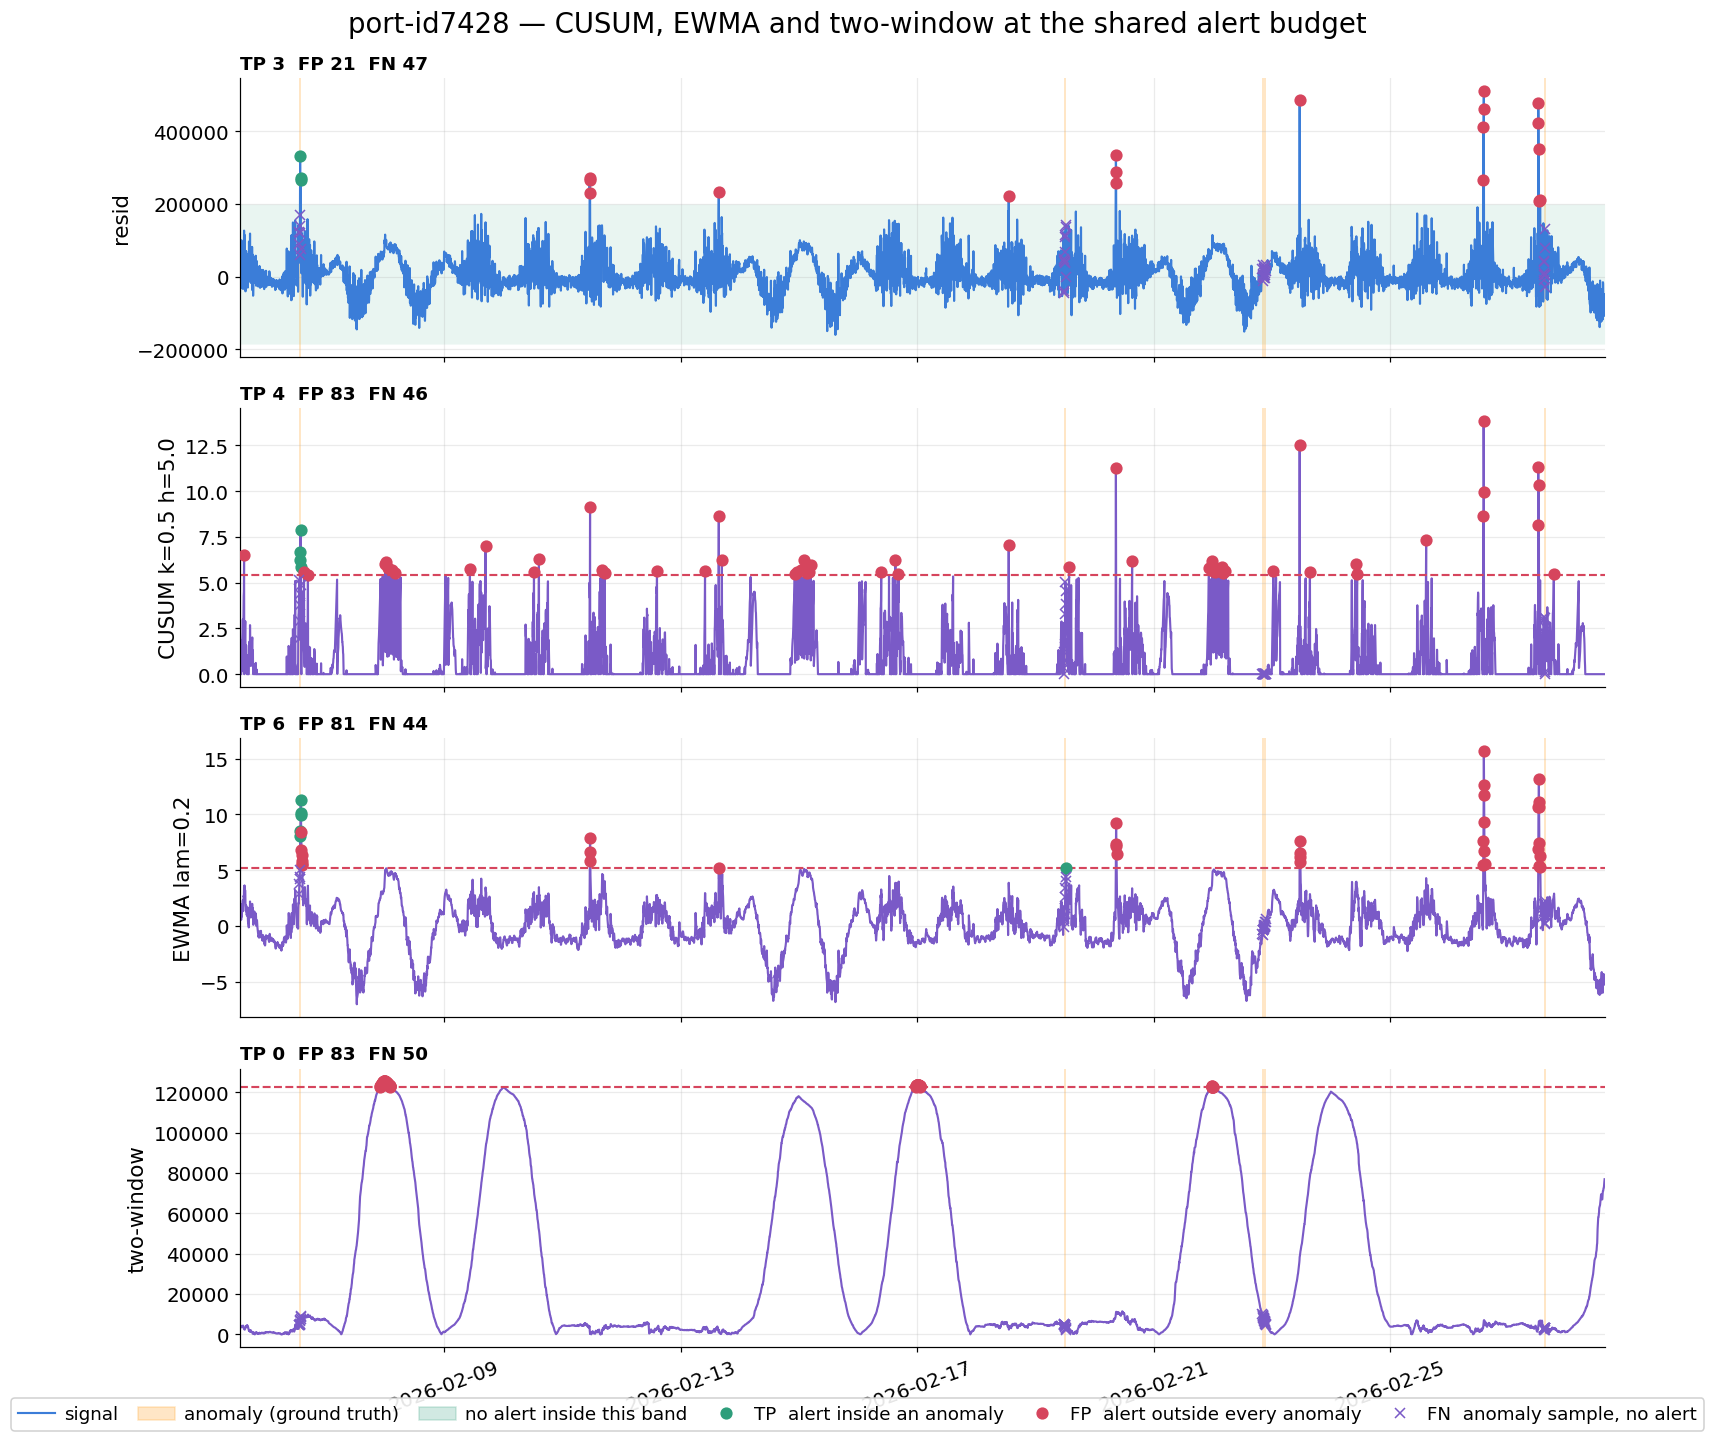

In [11]:
plot_series(g, half=HALF, cadence=CADENCE, period=PERIOD,
           bands={"resid": (g["resid"], train.mean() - 4 * train.std(),
                            train.mean() + 4 * train.std())},
           scores={"CUSUM k=0.5 h=5.0": S_cusum, "EWMA lam=0.2": ew.to_numpy(),
                   "two-window": tw.to_numpy()},
           budget=BUDGET, title=f"{port} — CUSUM, EWMA and two-window at the shared alert budget")


Two structural notes worth more than the numbers.

- **CUSUM must run with no confirmation layer.**
  - It resets to zero the moment it signals.
  - Its statistic is above the limit for exactly one sample by construction.
  - Requiring two in a row charges it twice for a property it has, and silences it.
- **The general rule:** a confirmation layer gives a *memoryless* score persistence, so it is
  redundant on any statistic that carries state.
- **EWMA is late in both directions.**
  - It peaks after the raw score and decays more slowly.
  - It buys smoothness with delay at the start and a tail of alerts after the anomaly is over.

## Step 8 — Composing many features, and the failure hiding inside it

- **Scoring one column asks "is this feature unusual". Operations wants "is this port unusual"**
  — a composition question.
- **Cheapest composition: max absolute z across features.** Max, not mean — a mean dilutes (one
  feature screaming, six quiet, averages down to mild), while max lets any single feature clear
  the cutoff alone. What max discards is agreement: it can't tell one feature at 12 from six at
  12.
- **The interesting part:** what happens when the six degenerate features join in.

In [12]:
def robust_z_matrix(data=df, cols=None, ports=None, window=None, cap=50.0, floor_frac=0.05,
                    return_bands=False):
    """Absolute robust z for every column, per port, capped. Same length as data.

    The cap and the floor are numerical guards: without the floor a quiet stretch drives the MAD
    toward zero and any deviation scores in the thousands. Both are named here rather than buried,
    because the next cell is about what they do to the score's own distribution.

    return_bands=True also returns {col: (centre, scale)}, the rolling median and MAD each
    column's z was actually divided by. Composing several columns into one score discards the
    band — a max has no single signal left to draw one on — but any one column going in still
    has one, and that pair is what draws it.
    """
    cols = SCORABLE if cols is None else cols
    ports = PORTS if ports is None else ports
    window = WINDOW if window is None else window
    mp = max(3, window // 3)
    out, bands = {}, {}
    for col in cols:
        z = pd.Series(np.nan, index=data.index, dtype=float)
        centre = pd.Series(np.nan, index=data.index, dtype=float)
        scale = pd.Series(np.nan, index=data.index, dtype=float)
        for pid in ports:
            gi = data.index[data["port_id"] == pid]
            prev = data.loc[gi, col].shift(1)
            c = prev.rolling(window, min_periods=mp).median()
            sc = (prev - c).abs().rolling(window, min_periods=mp).median() * 1.4826
            whole = data.loc[gi, col].to_numpy(dtype=float)
            fl = max(floor_frac * 1.4826 * np.median(np.abs(whole - np.median(whole))), 1e-12)
            sc = sc.fillna(fl).clip(lower=fl)
            z.loc[gi] = ((data.loc[gi, col] - c) / sc).clip(-cap, cap)
            centre.loc[gi], scale.loc[gi] = c, sc
        out[col] = z.abs()
        bands[col] = (centre, scale)
    scores = pd.DataFrame(out, index=data.index)
    return (scores, bands) if return_bands else scores


CAP = 50.0            # the score cap, and the whole subject of this step
WINDOW = 12           # rolling window in samples, one hour. Lab 01 Step 9 is why
z_scorable = robust_z_matrix(data=df, cols=SCORABLE, ports=PORTS, window=WINDOW,
                             cap=CAP, floor_frac=0.05)
z_all = robust_z_matrix(data=df, cols=FEATURES, ports=PORTS, window=WINDOW,
                        cap=CAP, floor_frac=0.05)
score_scorable = z_scorable.max(axis=1)
score_all = z_all.max(axis=1)

for name, sc in [(f"max abs z over {len(SCORABLE)} scorable", score_scorable),
                 (f"max abs z over all {len(FEATURES)}", score_all)]:
    at_cap = float((sc >= CAP - 1e-9).mean())
    print(f"{name:32} at the cap {at_cap:7.2%} | q0.99 {np.nanquantile(sc.dropna(), 0.99):8.3f}"
          f" | q0.995 {np.nanquantile(sc.dropna(), 0.995):8.3f}")

max abs z over 7 scorable        at the cap   0.37% | q0.99    7.668 | q0.995   10.943
max abs z over all 13            at the cap  11.76% | q0.99   50.000 | q0.995   50.000


### The composed score, on one port

One feature's band, then `score_scorable`: the max across all seven, alerting at the shared
budget.

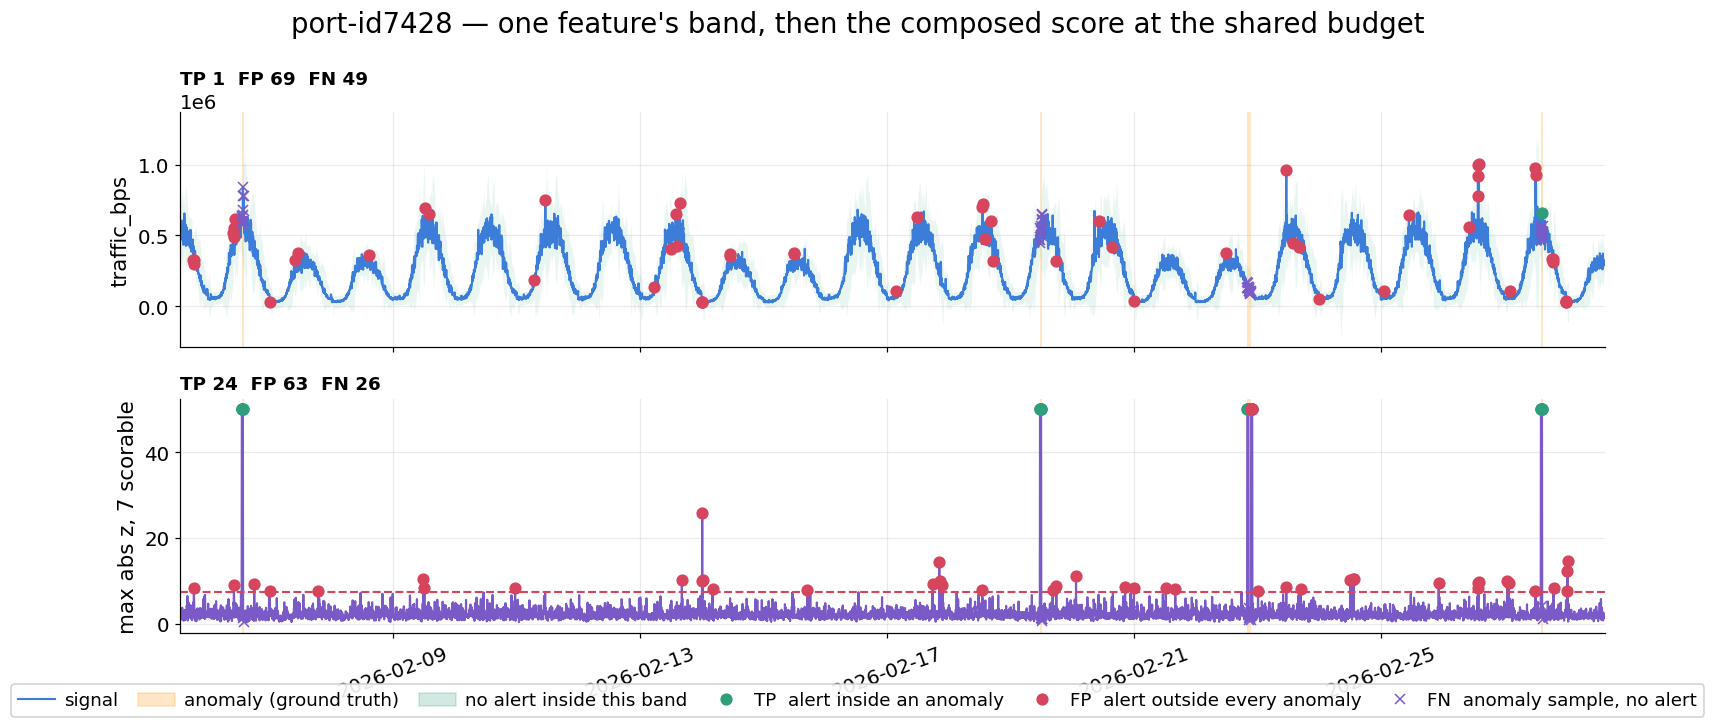

In [13]:
port8, demo_col = PORTS[1], COLUMNS[0]
g8 = series_of(port=port8, col=demo_col, data=df)
sc_port8 = score_scorable.loc[df.index[df["port_id"] == port8]].to_numpy()

_, demo_bands = robust_z_matrix(data=df, cols=[demo_col], ports=PORTS, window=WINDOW,
                                cap=CAP, floor_frac=0.05, return_bands=True)
centre8, scale8 = (s.loc[df.index[df["port_id"] == port8]].to_numpy()
                   for s in demo_bands[demo_col])

plot_series(g8, half=HALF, cadence=CADENCE, period=PERIOD,
           bands={demo_col: (g8["value"], centre8 - 4 * scale8, centre8 + 4 * scale8)},
           scores={f"max abs z, {len(SCORABLE)} scorable": sc_port8},
           budget=BUDGET,
           title=f"{port8} — one feature's band, then the composed score at the shared budget")


Read the two `q0.995` numbers.

- **Seven scorable features:** 0.17% of samples reach the cap, and the 99.5th percentile is **11.6**
  — an ordinary number, so a quantile threshold means something.
- **All thirteen:** 4.7% of samples sit at exactly **50.0**, which puts both the 99th and the 99.5th
  percentile *on* the cap, and no sample can exceed it.

**The score has not stopped working as a rule** — a cutoff of 4 still separates. **It has stopped
working as a ranking,** and that removes the foundation under everything built on ranking: quantile
thresholds, alert budgets, precision-recall curves, every sweep in this notebook.

A guard rail chosen for numerical safety changed the statistical properties of the score. That is why
a cap belongs in a spec the next stage can read, not inside a helper function.

In [14]:
tgt = df["event_label"].isin(ANOMALY_TYPES).to_numpy()
budget_rows = []
for name, sc in [("7 scorable", score_scorable), ("all 13", score_all)]:
    # A pooled quantile would let whichever port's score runs hottest eat the shared budget, so
    # each port gets its own 99.5th percentile even though the underlying z is already per-port.
    per_port_q = sc.groupby(df["port_id"]).transform(lambda s: s.quantile(0.995))
    for rule, thr, fired in [("abs z > 4", 4.0, sc > 4.0),
                             ("q = 0.995 per port", per_port_q, sc > per_port_q)]:
        m = fired.fillna(False).to_numpy()
        thr_shown = (round(float(thr), 3) if np.isscalar(thr) else
                    f"{thr.groupby(df['port_id']).first().min():.2f}"
                    f"–{thr.groupby(df['port_id']).first().max():.2f}")
        budget_rows.append({"columns": name, "rule": rule, "threshold": thr_shown,
                            "alerts": int(m.sum()), "hits_in_anomaly": int((m & tgt).sum()),
                            "alerts_per_day": round(float((m & ~tgt).sum()) / DAYS, 2)})
pd.DataFrame(budget_rows)


,columns,rule,threshold,alerts,hits_in_anomaly,alerts_per_day
0,7 scorable,abs z > 4,4.0,3683,107,119.20
1,7 scorable,q = 0.995 per port,9.19–15.04,220,100,4.00
2,all 13,abs z > 4,4.0,8169,131,267.93
3,all 13,q = 0.995 per port,50.00–50.00,0,0,0.00


- **The `q = 0.995` row on all 13 columns is the one to sit with.** Threshold equals cap,
  comparison strict, detector emits nothing. No crash, no warning — a dashboard built on it looks
  healthy for as long as anyone watches.

### The ordering bug, which is the same class of failure

- **Score the incoming sample against the window, then append it.** Reverse those two lines and
  the code raises nothing, draws a plausible chart, and destroys recall in proportion to the
  anomaly's size — the anomaly is now inside the baseline it's judged against.
- **Measure it rather than trusting a comment.**

In [15]:
col, port = "traffic_bps", PORTS[1]
g = series_of(port=port, col=col, data=df)
v, w, mp = g["value"], WINDOW, max(3, WINDOW // 3)
tgt = g["target"].to_numpy()

rows_o = []
for kind in ("mean", "robust"):
    if kind == "mean":
        c_ok, s_ok = v.shift(1).rolling(w, min_periods=mp).mean(), v.shift(1).rolling(w, min_periods=mp).std()
        c_bug, s_bug = v.rolling(w, min_periods=mp).mean(), v.rolling(w, min_periods=mp).std()
    else:
        c_ok = v.shift(1).rolling(w, min_periods=mp).median()
        s_ok = (v.shift(1) - c_ok).abs().rolling(w, min_periods=mp).median() * 1.4826
        c_bug = v.rolling(w, min_periods=mp).median()
        s_bug = (v - c_bug).abs().rolling(w, min_periods=mp).median() * 1.4826
    ok = ((v - c_ok).abs() / s_ok.clip(lower=1e-12)).clip(upper=CAP)
    bug = ((v - c_bug).abs() / s_bug.clip(lower=1e-12)).clip(upper=CAP)
    rows_o.append({"estimator": kind,
                   "correct peak": round(float(ok[tgt].max()), 2),
                   "bug peak": round(float(bug[tgt].max()), 2),
                   "correct samples > 4": int((ok[tgt] > 4).sum()),
                   "bug samples > 4": int((bug[tgt] > 4).sum()),
                   "of": int(tgt.sum())})
pd.DataFrame(rows_o)

,estimator,correct peak,bug peak,correct samples > 4,bug samples > 4,of
0,mean,5.12,2.68,1,0,50
1,robust,4.10,3.69,1,0,50


**The same one-line error costs the mean baseline everything and the robust one a third.**

- **Mean:** peak score 14.81 → 3.10, and all three samples that cleared the cutoff stop clearing it.
  The detector goes from finding the anomaly to finding nothing.
- **Robust:** peak does not move at all; count falls 9 → 6.
- **Why:** a mean has a breakdown point of zero, so one contaminating sample moves it. A median needs
  more than half the window, and one sample in twelve is nowhere near it.

**That is the opposite of the usual advice.** Robustness is sold as protection against dirty data.
Here it also bought protection against a coding error — and neither the test suite nor the chart
would have told you which implementation you were running.

**Both failures in this step share a shape:** nothing raised, nothing logged, output still plausible.
A pipeline that fails loudly is a pipeline you can fix.

## Step 9 — Everything side by side

Every point-wise method at the same alert budget, so the comparison is about the method rather
than about how loudly it was tuned.

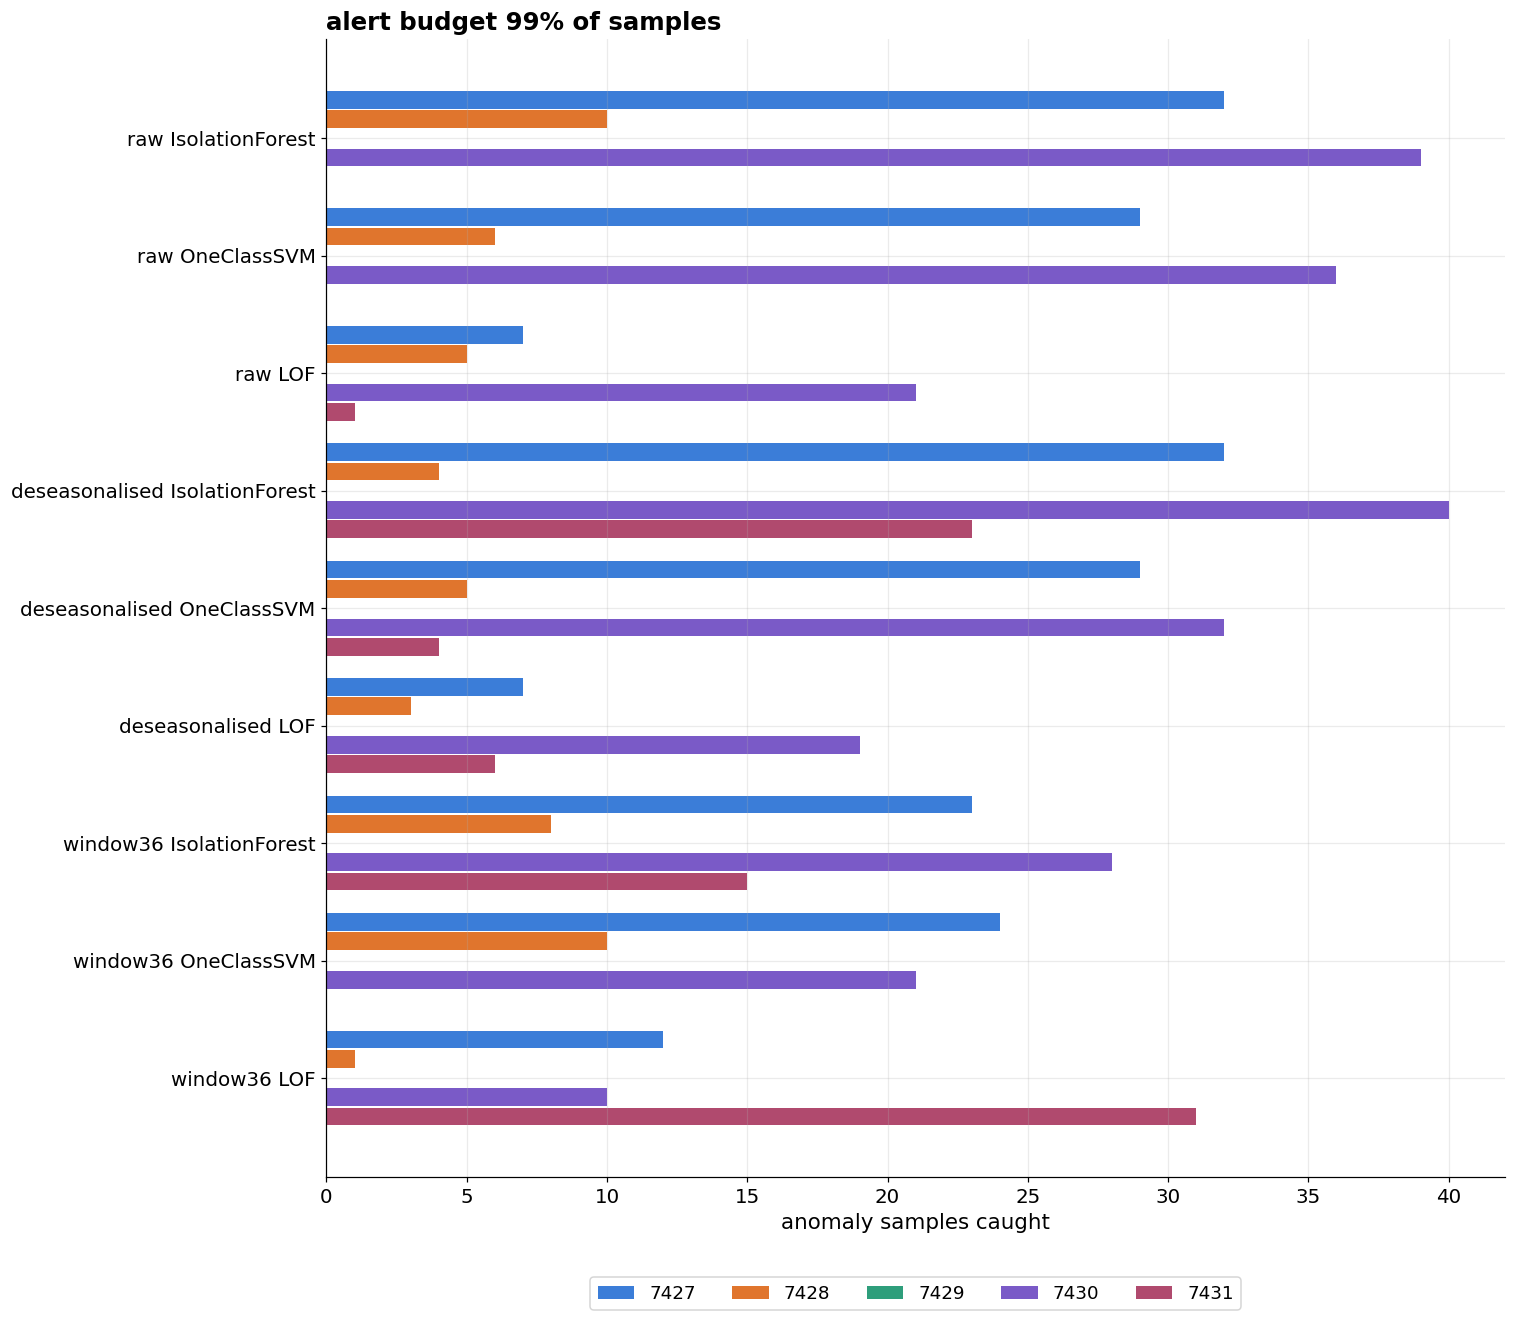

,port,method,alerts,caught,of,precision,column
0,7427,raw IsolationForest,87,32,62,0.368,traffic_bps
1,7427,raw OneClassSVM,87,29,62,0.333,traffic_bps
2,7427,raw LOF,87,7,62,0.080,traffic_bps
3,7427,deseasonalised IsolationForest,85,32,62,0.376,traffic_bps
4,7427,deseasonalised OneClassSVM,87,29,62,0.333,traffic_bps
5,7427,deseasonalised LOF,87,7,62,0.080,traffic_bps
6,7427,window36 IsolationForest,87,23,62,0.264,traffic_bps
7,7427,window36 OneClassSVM,87,24,62,0.276,traffic_bps
8,7427,window36 LOF,87,12,62,0.138,traffic_bps
9,7428,raw IsolationForest,86,10,50,0.116,traffic_bps


In [16]:
summary = (pd.DataFrame(rows).drop_duplicates(subset=["port", "method"])
           .pivot(index="method", columns="port", values="caught").fillna(0).astype(int))
order = [f"{p} {m}" for p in ("raw", "deseasonalised", f"window{N_INPUT}")
         for m in ("IsolationForest", "OneClassSVM", "LOF")]
summary = summary.reindex([m for m in order if m in summary.index])

# One sub-bar per port, so the figure has to grow with the port count, not just the method
# count: five ports at a fixed row height collapse into one smear. bar_h keeps every group at a
# constant fraction of its row regardless of how many ports are configured.
n_ports = len(summary.columns)
bar_h = 0.82 / n_ports
w, h = plt.rcParams["figure.figsize"]
fig, ax = plt.subplots(figsize=(w, (0.16 * n_ports + 0.35) * len(summary) + 1.8))
y = np.arange(len(summary))
for k, port in enumerate(summary.columns):
    ax.barh(y + (k - (n_ports - 1) / 2) * bar_h, summary[port], height=bar_h * 0.92,
            color=PORT_C[k % len(PORT_C)], label=port)
ax.set_yticks(y, summary.index)
ax.invert_yaxis()
ax.set(xlabel="anomaly samples caught", title=f"alert budget {BUDGET:.0%} of samples")
ax.legend(ncol=n_ports, loc="upper center", bbox_to_anchor=(0.5, -0.08))
plt.show()

pd.DataFrame(rows).drop_duplicates(subset=["port", "method"])


Read the plane by column, not by method.

- **No method wins everywhere,** and the differences between columns are larger than the differences
  between methods on one column.
- **The framing decides more than the model does.** Deseasonalising ranges from a small gain on
  `traffic_bps` to a 4.6× loss on `multicast_ratio`, while the three models sit within 8% of each
  other overall.
- **That is the lab's actual result,** and it is more useful than a ranking would have been.

### Which to reach for first

| situation | first choice |
|---|---|
| a hard limit exists | a rule: safety ceiling, SLO, error budget |
| one signal, clear pattern | a statistical baseline; check the cycle exists before removing it |
| several signals interacting | ML, but only after a fixed threshold and a rolling z-score |

These layer rather than compete. A fixed threshold under a statistical baseline under a model is a
normal production stack, not indecision.


## Exercises

Five measurements, then four designs that need what you know about your own network.

### Measure it

1. **Window length.** `N_INPUT` to `12`, then `288`, re-run Step 5.
   - At `288` detection collapses — explain it from the definition of the window.
   - Check against Lab 01 Step 16a.
   - `N_INPUT` arrives through the spec: a permanent change belongs in Lab 01, a temporary one below
     Step 3.
2. **CUSUM slack.** `k` to `0.25`, then `3.0`. How does the alarm count move, and which value would
   you defend to an on-call team?
3. **EWMA memory.** `lam` to `0.05`, then `0.8`.
   - Watch alert count *and* delay to first alert.
   - Then remove the `/ limit` and re-run: which λ still fires, and does
     `implied_threshold_if_unscaled` explain which do not?
4. **The cap.** `CAP = 1e6`, effectively removing it.
   - The `q = 0.995` row on all 13 columns comes back to life.
   - What replaces the cap as the failure, and which would you rather debug at 03:00?
5. **Composition rule.** Swap `max(axis=1)` for `mean(axis=1)`, then `(z > 4).sum(axis=1)`.
   - Max ignores agreement, mean dilutes, voting needs a quorum you choose.
   - Score all three at `q = 0.995` and say which you would ship.

### Design it

6. **Which family fits your team?**
   - The real difference is maintenance, not accuracy.
   - A fixed rule needs a human to pick a line per metric, then holds forever.
   - A model needs someone to confirm the training period still represents normal.
   - Which cost can your team carry, and what would make the other affordable?
7. **Explain a model score to your on-call.**
   - A z of 4 is four standard deviations. An isolation score of 0.6384 is indefensible in a review.
   - Draft the two sentences for the alert payload, then decide whether they justify waking someone.
   - If not, that argues for a statistical detector *in front of* the model.
8. **Design the seasonal bucket your traffic has.**
   - Lab 01's `decompose` assumes one daily period.
   - Write the key one service you support would need, and how much history each bucket requires.
9. **Pick the swap that would break production.**
   - Everything downstream of the score is detector-agnostic except the threshold.
   - Write what happens if someone swaps a scoring function and leaves the constant.
   - Then write the check that would have caught it. It is easier to write than the incident review.


In [17]:
# YOUR CODE HERE

## Summary

- **A contract beats a convention.** This lab recomputes no feature and refits no scaler. It asserts
  the frame matches the spec and stops if it does not.
- **The framing decides more than the model.** Three detectors sit within 8% of each other overall,
  while one framing choice swings recall by 4.6× on a single column.
- **A transform that assumes a cycle, used where there is none, destroys signal.** Deseasonalising
  `multicast_ratio` takes 705 caught samples down to 154. Lab 01 measured the missing cycle before a
  model ran; running the model anyway would have looked like a modelling failure.
- **State buys persistence and costs latency.** CUSUM needs no confirmation layer; EWMA is late in
  both directions; both need their scale stated or the threshold silently moves.
- **A guard rail changes the statistics it guards.** The score cap turns a working ranking into a
  constant, and every quantile built on it dies quietly.
- **A change point is an investigation, not a verdict.** The largest level changes this month are
  weekends.

Both labs scored one signal at a time. The anomalies that stayed hardest — the ones needing a
**ratio** between two counters read together — are where multivariate detection starts.